# Twist and jumps
Understanding the jumps in adj_close_price and how to handle them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, probplot
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── DATA LOADING & STATISTICS HELPERS ─────────────────────────────────────

def extract_ticker(filename):
    # text between first and second underscore in the stem
    parts = Path(filename).stem.split('_')
    return parts[1] if len(parts) > 1 else Path(filename).stem


def load_csvs(folder, value_col):
    folder = Path(folder)
    data = {}
    for csv_file in sorted(folder.glob('*.csv')):
        ticker = extract_ticker(csv_file.name)
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
        data[ticker] = df[value_col]
    print(f'Loaded {len(data)} tickers from: {folder}')
    return data


def analyze_nans(data_dict):
    rows = [{'Ticker': t, 'NaN Count': int(s.isna().sum())} for t, s in data_dict.items()]
    nan_df = pd.DataFrame(rows)
    has_nans = nan_df[nan_df['NaN Count'] > 0]
    if has_nans.empty:
        print('No NaN values found in any ticker.')
    else:
        print(f'Tickers with NaN values ({len(has_nans)} of {len(data_dict)}):')
        print(has_nans.to_string(index=False))
    print(f'Total NaNs across all tickers: {nan_df["NaN Count"].sum()}')
    return {t: s.dropna() for t, s in data_dict.items()}


def compute_ticker_stats(series, ticker):
    vals = series.values
    desc = series.describe()
    return {
        'ticker':   ticker,
        'count':    desc['count'],
        'mean':     desc['mean'],
        'std':      desc['std'],
        'min':      desc['min'],
        'q25':      desc['25%'],
        'median':   desc['50%'],
        'q75':      desc['75%'],
        'max':      desc['max'],
        'skewness': float(skew(vals)),
        'kurtosis': float(kurtosis(vals)),
    }


def compute_all_stats(data_dict):
    rows = [compute_ticker_stats(s, t) for t, s in data_dict.items()]
    return pd.DataFrame(rows).set_index('ticker')


def compute_returns(data_dict):
    result = {t: np.log(s / s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Log-returns computed for {len(result)} tickers (first row dropped).')
    return result

def compute_increments(data_dict):
    result = {t: (s - s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Relative returns computed for {len(result)} tickers (first row dropped).')
    return result


def normalize_individually(data_dict):
    result = {}
    for t, s in data_dict.items():
        mu, sigma = s.mean(), s.std()
        result[t] = (s - mu) / sigma if sigma > 0 else s - mu
    print(f'Z-score normalised {len(result)} tickers individually.')
    return result


def window_normalize(data_dict, window_size, stride):
    """
    For each ticker, extracts overlapping windows of length <window_size>
    with step <stride>, normalises each window by its own mean and std,
    and stores them as ticker_<window_number> entries.

    Windows that would exceed the series length are discarded.
    The returned dictionary is compatible with compute_all_stats,
    describe_stats, quantile_filter, etc.

    Example: window_size=2048, stride=400, n=10_000
        valid starting indices: 0, 400, ..., 7600  (20 windows)
    """
    result = {}
    window_counts = {}

    for ticker, series in data_dict.items():
        s = series.dropna()
        n = len(s)

        if n < window_size:
            print(f'  [{ticker}] skipped — only {n} obs, need {window_size}')
            continue

        # last valid start: largest k*stride such that k*stride + window_size <= n
        k_max = (n - window_size) // stride
        starts = [k * stride for k in range(k_max + 1)]

        for w_idx, start in enumerate(starts):
            window = s.iloc[start: start + window_size]
            mu, sigma = window.mean(), window.std()
            normalised = (window - mu) / sigma if sigma > 0 else window - mu
            result[f'{ticker}_{w_idx}'] = normalised

        window_counts[ticker] = len(starts)

    total_windows = len(result)
    avg_windows   = sum(window_counts.values()) / len(window_counts) if window_counts else 0
    print(f'window_normalize: window_size={window_size}, stride={stride}')
    print(f'  input tickers   : {len(data_dict)}')
    print(f'  output windows  : {total_windows:,}')
    print(f'  avg windows/csv : {avg_windows:.1f}')
    print(f'  min windows/csv : {min(window_counts.values())}  ({min(window_counts, key=window_counts.get)})')
    print(f'  max windows/csv : {max(window_counts.values())}  ({max(window_counts, key=window_counts.get)})')

    return result

def window_rebase(data_dict, window_size, stride):
    """
    For each ticker, extracts overlapping windows of length <window_size>
    with step <stride> and subtracts the window's first value from every
    element, so each window starts at 0.

    Windows that would exceed the series length are discarded.
    The returned dictionary is compatible with compute_all_stats,
    describe_stats, quantile_filter, etc.
    """
    result = {}
    window_counts = {}

    for ticker, series in data_dict.items():
        s = series.dropna()
        n = len(s)

        if n < window_size:
            print(f'  [{ticker}] skipped — only {n} obs, need {window_size}')
            continue

        k_max  = (n - window_size) // stride
        starts = [k * stride for k in range(k_max + 1)]

        for w_idx, start in enumerate(starts):
            window = s.iloc[start: start + window_size]
            result[f'{ticker}_{w_idx}'] = window - window.iloc[0]

        window_counts[ticker] = len(starts)

    total_windows = len(result)
    avg_windows   = sum(window_counts.values()) / len(window_counts) if window_counts else 0
    print(f'window_rebase: window_size={window_size}, stride={stride}')
    print(f'  input tickers   : {len(data_dict)}')
    print(f'  output windows  : {total_windows:,}')
    print(f'  avg windows/csv : {avg_windows:.1f}')
    print(f'  min windows/csv : {min(window_counts.values())}  ({min(window_counts, key=window_counts.get)})')
    print(f'  max windows/csv : {max(window_counts.values())}  ({max(window_counts, key=window_counts.get)})')

    return result


print('Data helpers defined.')

Data helpers defined.


In [3]:
def compute_jumps(data_dict, jump_size):
    """
    Counts jumps per ticker where abs(price_t - price_{t-1}) > price_{t-1} * jump_size.
    Returns a full Series (sorted desc) and the top-10 tickers.
    """
    jump_counts = {}
    for ticker, series in data_dict.items():
        prev = series.shift(1).dropna()
        curr = series.loc[prev.index]
        jump_counts[ticker] = int(((curr - prev).abs() > prev * jump_size).sum())

    jump_series = pd.Series(jump_counts).sort_values(ascending=False)
    top10 = jump_series.head(10)
    print(f"\njump_size={jump_size:.4f}  |  total jumps: {jump_series.sum():,}  |  avg per ticker: {jump_series.mean():.2f}")
    print("Top 10 tickers by jump count:")
    print(top10.to_string())
    return jump_series, top10


# Example call
# _ = compute_jumps(raw_clean, jump_size=0.05)

def compute_trim_counts(data_dict, percentage):
    """
    For each ticker, counts observations outside the
    [percentage/2, 1 - percentage/2] quantile band.
    Returns a full Series (sorted desc) and the top-10 tickers.

    Example: percentage=0.02 removes values below the 1st percentile
             and above the 99th percentile.
    """
    lo_q = percentage / 2
    hi_q = 1.0 - percentage / 2
    trim_counts = {}
    for ticker, series in data_dict.items():
        lo = series.quantile(lo_q)
        hi = series.quantile(hi_q)
        trim_counts[ticker] = int(((series < lo) | (series > hi)).sum())

    trim_series = pd.Series(trim_counts).sort_values(ascending=False)
    top10 = trim_series.head(10)
    pct_str = f'{percentage * 100:.3g}%'
    print(f"\npercentage={pct_str}  |  total records removed: {trim_series.sum():,}  |  avg per ticker: {trim_series.mean():.2f}")
    print(f"  (lower tail < {lo_q*100:.3g}%-quantile,  upper tail > {hi_q*100:.3g}%-quantile)")
    print("Top 10 tickers by records removed:")
    print(top10.to_string())
    return trim_series, top10


# # Example call
# _ = compute_trim_counts(raw_clean, percentage=0.02)

def compute_consecutive_duplicates(data_dict):
    """
    For each ticker, counts rows where price_t == price_{t-1} (consecutive duplicates)
    and expresses that count as a percentage of the ticker's total observations.
    Returns a DataFrame (sorted by count desc) and the top-10 tickers.
    """
    rows = {}
    for ticker, series in data_dict.items():
        n_obs  = len(series)
        n_dups = int((series == series.shift(1)).sum())
        rows[ticker] = {'count': n_dups, 'total': n_obs, 'pct': n_dups / n_obs * 100}

    dup_df = pd.DataFrame(rows).T.sort_values('count', ascending=False)
    dup_df[['count', 'total']] = dup_df[['count', 'total']].astype(int)

    top10 = dup_df.head(10)

    print(f"Total consecutive duplicates across all tickers : {dup_df['count'].sum():,}")
    print(f"Average per ticker                              : {dup_df['count'].mean():.2f}")
    print(f"Average % per ticker                            : {dup_df['pct'].mean():.4f}%")
    print("\nTop 10 tickers by consecutive duplicate count:")
    print(top10.to_string(float_format=lambda x: f'{x:.4f}'))

    return dup_df, top10





In [4]:
# ── VISUALISATION & ANALYSIS HELPERS ──────────────────────────────────────

def describe_stats(stats_df, label=''):
    sep = '=' * 65
    print(f'\n{sep}')
    print(f'Distribution of per-ticker statistics  [{label}]')
    print(sep)
    print(stats_df.describe().round(6).to_string())


def plot_stat_histograms(stats_df, label='', bins=30):
    cols = list(stats_df.columns)
    n = len(cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for i, col in enumerate(cols):
        axes_flat[i].hist(stats_df[col].dropna(), bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
        axes_flat[i].set_title(col)
        axes_flat[i].set_xlabel('Value')
        axes_flat[i].set_ylabel('Count')
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f'Per-ticker statistics distributions  [{label}]', fontsize=13)
    plt.tight_layout()
    plt.show()


def quantile_filter(stats_df, quantile_level=0.9):
    thresholds = stats_df.quantile(quantile_level)
    pct = f'{quantile_level:.0%}'
    print(f'\n{pct}-quantile thresholds per statistic:')
    print(thresholds.round(6).to_string())
    mask = (stats_df > thresholds).any(axis=1)
    outliers_any = stats_df[mask].copy()
    print(f'\nTickers exceeding at least one {pct} threshold: {len(outliers_any)}')
    print(outliers_any.round(4).to_string())

    mask = (stats_df > thresholds).all(axis=1)
    outliers_all = stats_df[mask].copy()
    print(f'\nTickers exceeding all {pct} threshold: {len(outliers_all)}')
    print(outliers_all.round(4).to_string())

    return outliers_any, outliers_all


def plot_ticker_histograms(data_dict, tickers, label='', bins=50):
    found   = [t for t in tickers if t in data_dict]
    missing = [t for t in tickers if t not in data_dict]
    if missing:
        print(f'Tickers not found: {missing}')
    for ticker in found:
        s = data_dict[ticker].dropna()
        stats = s.describe()
        stats['skewness'] = skew(s.values)
        stats['kurtosis'] = kurtosis(s.values)
        print(f'\n── {ticker}  [{label}] ──')
        print(stats.round(6).to_string())

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

        ax1.hist(s, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
        ax1.set_title(f'{ticker}  [{label}]')
        ax1.set_xlabel('Value')
        ax1.set_ylabel('Count')

        ax2.scatter(s.index, s.values, s=2, alpha=0.5, color='steelblue')
        ax2.set_title(f'{ticker}  [{label}] — time series')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Value')

        plt.tight_layout()
        plt.show()





def compute_aggregate_stats_and_plot(data_dict, label='', bins=200):
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    agg = {
        'count':    len(all_vals),
        'mean':     float(np.mean(all_vals)),
        'std':      float(np.std(all_vals)),
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'kurtosis': float(kurtosis(all_vals)),
    }
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    print(sep)
    for k, v in agg.items():
        print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(all_vals, bins=bins, density=True, alpha=0.7, color='mediumseagreen', edgecolor='none')
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density')
    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    return agg


def compute_aggregate_stats_and_plot_std(data_dict, label='', n_stds=2, bins_per_std=100):
    """Like compute_aggregate_stats_and_plot, but bin edges are defined in units of std.
    
    n_stds      : how many std deviations to cover on each side of the mean
    bins_per_std: number of bins per std unit (total bins = 2 * n_stds * bins_per_std)
    """
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    mu    = float(np.mean(all_vals))
    sigma = float(np.std(all_vals))

    agg = {
        'count':    len(all_vals),
        'mean':     mu,
        'std':      sigma,
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'skewness': float(kurtosis(all_vals)),
    }
    # sep = '=' * 55
    # print(f'\n{sep}')
    # print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    # print(sep)
    
    # for k, v in agg.items():
    #     print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')

    # bin edges at regular std intervals
    bin_edges = np.linspace(mu - n_stds * sigma, mu + n_stds * sigma,
                            num=2 * n_stds * bins_per_std + 1)
    # std-unit tick positions and labels for the x-axis
    std_ticks  = np.arange(-n_stds, n_stds + 1)
    std_labels = [f'{k:+d}σ' if k != 0 else 'μ' for k in std_ticks]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(all_vals, bins=bin_edges, density=True, alpha=0.7,
             color='mediumseagreen', edgecolor='none')
    ax1.set_xticks(mu + std_ticks * sigma)
    ax1.set_xticklabels(std_labels)
    ax1.set_xlim(bin_edges[0], bin_edges[-1])
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel(f'Value  (bin width = σ/{bins_per_std})')
    ax1.set_ylabel('Density')

    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return agg

def plot_ticker_duplicate_timeline(data_dict, ticker, freq='W'):
    """
    Shows where consecutive duplicate values are concentrated in time
    for a single ticker.

    freq : resample frequency — 'D' daily, 'W' weekly, 'ME' monthly, 'YE' yearly
    """
    if ticker not in data_dict:
        print(f'Ticker {ticker!r} not found.')
        return

    series = data_dict[ticker]
    dup_flag = (series == series.shift(1)).astype(int)
    dup_flag.index.name = 'date'

    resampled = dup_flag.resample(freq).sum()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

    # ── top: raw price with duplicate dates highlighted ────────────────────
    dup_dates = series.index[dup_flag == 1]
    ax1.plot(series.index, series.values, lw=0.8, color='steelblue', label='Price')
    ax1.scatter(dup_dates, series.loc[dup_dates].values,
                color='crimson', s=10, zorder=3, label='Duplicate')
    ax1.set_title(f'{ticker} — price series with consecutive duplicates highlighted')
    ax1.set_ylabel('Price')
    ax1.legend(markerscale=2)

    # ── bottom: duplicate count over time (resampled) ──────────────────────
    ax2.bar(resampled.index, resampled.values,
            width=resampled.index.to_series().diff().median().days * 0.8,
            color='crimson', alpha=0.7, edgecolor='none')
    freq_label = {'D': 'Daily', 'W': 'Weekly', 'ME': 'Monthly', 'YE': 'Yearly'}.get(freq, freq)
    ax2.set_title(f'{ticker} — {freq_label} duplicate count')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('# duplicates')

    plt.tight_layout()
    plt.show()

    print(f'\n{ticker}  |  total duplicates: {int(dup_flag.sum())}  '
          f'({dup_flag.mean()*100:.3f}% of {len(series)} obs)')
    print(f'First duplicate : {dup_dates[0].date() if len(dup_dates) else "none"}')
    print(f'Last duplicate  : {dup_dates[-1].date() if len(dup_dates) else "none"}')

print('Visualisation helpers defined.')

Visualisation helpers defined.


---
## Section 1 — Loading the data

Data folder: `../data/raw_replication`  |  Column: `adj_close`

In [5]:
# 1.1  Load
raw_data = load_csvs('../data/raw_replication', 'adj_close')
log_data = load_csvs('../data/log_replication', 'log_adj_close')
print("Lenght of raw_data:", len(raw_data), "Lenght of log_data:", len(log_data))

raw_clean = analyze_nans(raw_data)
log_clean = analyze_nans(log_data)
print("Lenght of raw_clean:", len(raw_clean), "Lenght of log_clean:", len(log_clean))

returns_data = compute_returns(raw_clean)
increments_data = compute_increments(raw_clean)
print("Lenght of returns_data:", len(returns_data), "Lenght of increments_data:", len(increments_data))

returns_clean = analyze_nans(returns_data)
increments_clean = analyze_nans(increments_data)
print("Lenght of returns_clean:", len(returns_clean), "Lenght of increments_clean:", len(increments_clean))

Loaded 210 tickers from: ..\data\raw_replication
Loaded 210 tickers from: ..\data\log_replication
Lenght of raw_data: 210 Lenght of log_data: 210
No NaN values found in any ticker.
Total NaNs across all tickers: 0
No NaN values found in any ticker.
Total NaNs across all tickers: 0
Lenght of raw_clean: 210 Lenght of log_clean: 210
Log-returns computed for 210 tickers (first row dropped).
Relative returns computed for 210 tickers (first row dropped).
Lenght of returns_data: 210 Lenght of increments_data: 210
No NaN values found in any ticker.
Total NaNs across all tickers: 0
No NaN values found in any ticker.
Total NaNs across all tickers: 0
Lenght of returns_clean: 210 Lenght of increments_clean: 210


In [6]:
raw_stats = compute_all_stats(raw_clean)
# describe_stats(raw_stats, 'Daily Prices')

log_stats = compute_all_stats(log_clean)
# describe_stats(log_stats, 'Daily Log-Prices')

In [7]:
return_stats = compute_all_stats(returns_clean)
# describe_stats(return_stats, 'Daily Log-Returns')

increments_stats = compute_all_stats(increments_clean)
# describe_stats(increments_stats, 'Daily Log-increments')

# Jump analysis

In [8]:
_ = compute_jumps(raw_clean, jump_size=1.0)


jump_size=1.0000  |  total jumps: 0  |  avg per ticker: 0.00
Top 10 tickers by jump count:
AAPL    0
PPL     0
NI      0
NKE     0
NOC     0
NSC     0
NTRS    0
NUE     0
OKE     0
OMC     0


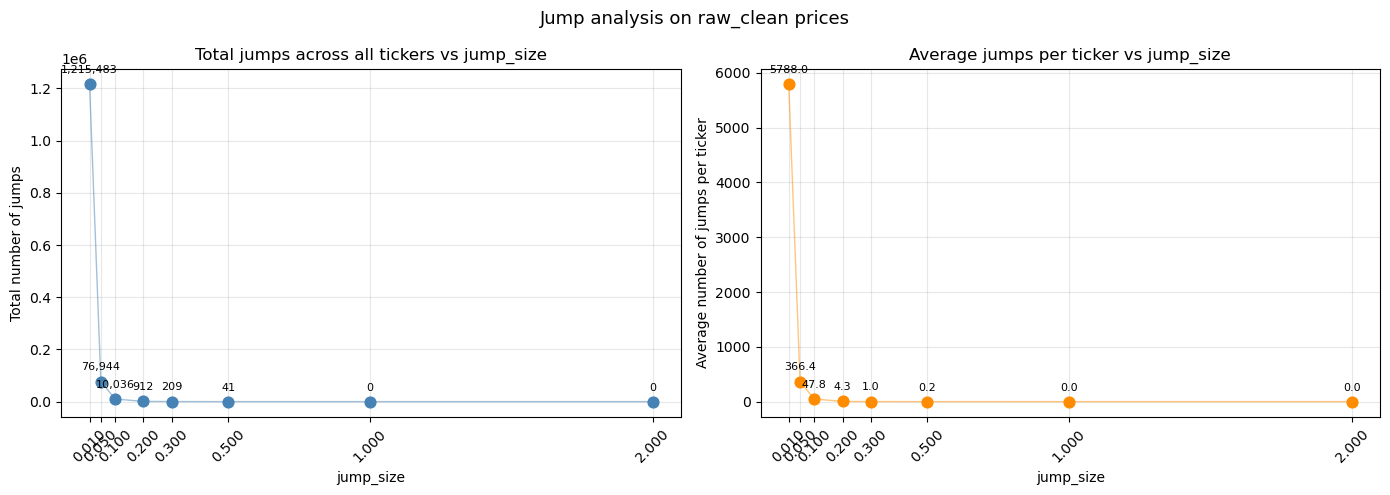

In [9]:
jump_sizes = [0.01, 0.05, 0.10, 0.20, 0.30, 0.5, 1.0, 2.0]

total_jumps  = []
avg_jumps    = []

for js in jump_sizes:
    counts = {}
    for ticker, series in raw_clean.items():
        prev = series.shift(1).dropna()
        curr = series.loc[prev.index]
        counts[ticker] = int(((curr - prev).abs() > prev * js).sum())
    s = pd.Series(counts)
    total_jumps.append(s.sum())
    avg_jumps.append(s.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(jump_sizes, total_jumps, color='steelblue', s=60, zorder=3)
ax1.plot(jump_sizes, total_jumps, color='steelblue', alpha=0.5, lw=1)
for x, y in zip(jump_sizes, total_jumps):
    ax1.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax1.set_title('Total jumps across all tickers vs jump_size')
ax1.set_xlabel('jump_size')
ax1.set_ylabel('Total number of jumps')
ax1.set_xticks(jump_sizes)
ax1.set_xticklabels([f'{js:.3f}' for js in jump_sizes], rotation=45)

ax2.scatter(jump_sizes, avg_jumps, color='darkorange', s=60, zorder=3)
ax2.plot(jump_sizes, avg_jumps, color='darkorange', alpha=0.5, lw=1)
for x, y in zip(jump_sizes, avg_jumps):
    ax2.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_title('Average jumps per ticker vs jump_size')
ax2.set_xlabel('jump_size')
ax2.set_ylabel('Average number of jumps per ticker')
ax2.set_xticks(jump_sizes)
ax2.set_xticklabels([f'{js:.3f}' for js in jump_sizes], rotation=45)

plt.suptitle('Jump analysis on raw_clean prices', fontsize=13)
plt.tight_layout()
plt.show()


 ### Removing some of the biggest jump datasets
 In particular are 4 those datasets that have jumps bigger than 100%, for a total of 4 jumps (one each):
 * BEN
 * HUBB
 * NVR
 * WMB

In [10]:
quantile_level = 0.9

In [11]:
# raw_stats = compute_all_stats(raw_clean)
describe_stats(raw_stats, 'Daily Prices')

raw_outliers_any, raw_outliers_all = quantile_filter(raw_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Prices]
              count        mean         std         min         q25      median         q75          max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000  210.000000  210.000000
mean   12493.809524   33.501820   47.652487    0.506268    2.974827   12.876072   42.697168   234.559556    1.697442    2.924138
std     1699.903952   24.634673   42.082296    0.647448    2.765973    8.155869   29.271431   230.180371    0.737001    4.813020
min    10084.000000    4.609644    3.839570    0.001410    0.025950    0.497044    6.576248    19.003372    0.373959   -1.440364
25%    11494.250000   17.224999   20.358901    0.115278    1.178369    7.194626   22.064031    86.786425    1.237979    0.391497
50%    11611.000000   26.997282   36.119734    0.323738    2.454899   10.623137   36.643080   167.867485    1.611462    1.674796
75%    13397.000000   43.947694   61.18564

In [12]:
print("Std outliers")
raw_outliers_any[raw_outliers_any['std'] > raw_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10)

Std outliers


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AIG,13431.0,203.667744,294.591087,4.374003,25.518789,51.289627,200.185715,1216.865723,1.533876,0.813225
GWW,13397.0,127.048239,231.353635,1.011217,5.534167,28.490551,162.096863,1207.812378,2.722498,7.192437
KLAC,11468.0,91.243741,211.727616,0.317436,2.594216,20.925836,46.273741,1737.280029,3.775386,16.337966
LLY,13577.0,75.532441,178.984095,0.500008,2.034345,24.013866,41.747601,1108.090454,3.657077,13.154831
TMO,11611.0,107.652620,170.904392,0.810649,9.335270,27.737226,117.846886,659.204956,1.850805,2.005769
PH,11611.0,88.073195,158.366219,1.347710,5.004830,21.545246,94.605621,1023.020020,3.045414,10.038364
TYL,11611.0,87.457097,152.975301,0.708247,2.500000,7.000000,102.580002,646.739990,1.873426,2.364908
NOC,11158.0,103.148620,152.403468,1.892941,7.923947,29.661541,133.147827,768.020020,1.736240,2.020874
UNH,10450.0,93.409389,147.473290,0.065878,4.103596,22.788620,100.590141,603.201294,1.778161,1.929865


In [13]:
# print("Skewness outliers")
# raw_outliers_any[raw_outliers_any['skewness'] > raw_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

In [14]:

# print("Kurtosis outliers")
# raw_outliers_any[raw_outliers_any['kurtosis'] > raw_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

In [15]:
# describe_stats(increments_stats, 'Daily Log-increments')
# return_stats = compute_all_stats(returns_clean)
describe_stats(return_stats, 'Daily Log-Returns')

return_outliers_any, return_outliers_all = quantile_filter(return_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-Returns]
              count        mean         std         min         q25      median         q75         max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000
mean   12492.809524    0.000458    0.020481   -0.310232   -0.009053    0.000004    0.009940    0.224658   -0.567837   28.035091
std     1699.903952    0.000132    0.005418    0.155030    0.002484    0.000036    0.002388    0.100340    1.371693   48.716877
min    10083.000000    0.000129    0.012167   -0.936258   -0.019802    0.000000    0.006006    0.102049  -10.238005    3.741907
25%    11493.250000    0.000383    0.016929   -0.352553   -0.009944    0.000000    0.008237    0.164169   -0.585283    8.471495
50%    11610.000000    0.000460    0.019455   -0.266636   -0.008565    0.000000    0.009501    0.199278   -0.269322   13.224475
75%    13396.000000    0.000531    0.022714 

In [16]:
# increments_stats = compute_all_stats(increments_clean)
describe_stats(increments_stats, 'Daily Log-increments')
increments_outliers_any, increments_outliers_all = quantile_filter(increments_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-increments]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000
mean   12492.809524    0.015312    1.044321  -21.444721   -0.086251    0.000033    0.110251   17.735522   -0.772639    70.446394
std     1699.903952    0.016860    0.951523   26.399588    0.063827    0.000406    0.074992   17.911531    2.249124   111.031130
min    10083.000000    0.000878    0.134478 -256.436768   -0.503279    0.000000    0.008328    1.545078  -20.149094    10.442881
25%    11493.250000    0.005369    0.433435  -24.382442   -0.116731    0.000000    0.055291    6.574421   -1.231155    31.487823
50%    11610.000000    0.009500    0.792144  -13.593843   -0.073295    0.000000    0.098226   11.269924   -0.560278    48.451796
75%    13396.000000    0.020804   

In [17]:
raw_filtered = raw_clean.copy()
# raw_filtered.pop('BEN')
# raw_filtered.pop('HUBB')
# raw_filtered.pop('NVR')
# raw_filtered.pop('WMB')
print("")

In [18]:
returns_filtered = returns_clean.copy()
# returns_filtered.pop('BEN')
# returns_filtered.pop('HUBB')
# returns_filtered.pop('NVR')
# returns_filtered.pop('WMB')

increments_filtered = increments_clean.copy()
# increments_filtered.pop('BEN')
# increments_filtered.pop('HUBB')
# increments_filtered.pop('NVR')
# increments_filtered.pop('WMB')
print("")

In [19]:
raw_stats = compute_all_stats(raw_filtered)
describe_stats(raw_stats, 'Daily Prices Filtered')

raw_outliers_any, raw_outliers_all = quantile_filter(raw_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Prices Filtered]
              count        mean         std         min         q25      median         q75          max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000  210.000000  210.000000
mean   12493.809524   33.501820   47.652487    0.506268    2.974827   12.876072   42.697168   234.559556    1.697442    2.924138
std     1699.903952   24.634673   42.082296    0.647448    2.765973    8.155869   29.271431   230.180371    0.737001    4.813020
min    10084.000000    4.609644    3.839570    0.001410    0.025950    0.497044    6.576248    19.003372    0.373959   -1.440364
25%    11494.250000   17.224999   20.358901    0.115278    1.178369    7.194626   22.064031    86.786425    1.237979    0.391497
50%    11611.000000   26.997282   36.119734    0.323738    2.454899   10.623137   36.643080   167.867485    1.611462    1.674796
75%    13397.000000   43.947694  

In [20]:
returns_stats = compute_all_stats(returns_filtered)
describe_stats(return_stats, 'Daily Log-Returns Filtered')

returns_outliers_any, returns_outliers_all = quantile_filter(returns_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-Returns Filtered]
              count        mean         std         min         q25      median         q75         max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000
mean   12492.809524    0.000458    0.020481   -0.310232   -0.009053    0.000004    0.009940    0.224658   -0.567837   28.035091
std     1699.903952    0.000132    0.005418    0.155030    0.002484    0.000036    0.002388    0.100340    1.371693   48.716877
min    10083.000000    0.000129    0.012167   -0.936258   -0.019802    0.000000    0.006006    0.102049  -10.238005    3.741907
25%    11493.250000    0.000383    0.016929   -0.352553   -0.009944    0.000000    0.008237    0.164169   -0.585283    8.471495
50%    11610.000000    0.000460    0.019455   -0.266636   -0.008565    0.000000    0.009501    0.199278   -0.269322   13.224475
75%    13396.000000    0.000531    

In [21]:
increments_stats = compute_all_stats(increments_filtered)
describe_stats(increments_stats, 'Daily Log-increments Filtered')

increments_outliers_any, increments_outliers_all = quantile_filter(increments_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-increments Filtered]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000
mean   12492.809524    0.015312    1.044321  -21.444721   -0.086251    0.000033    0.110251   17.735522   -0.772639    70.446394
std     1699.903952    0.016860    0.951523   26.399588    0.063827    0.000406    0.074992   17.911531    2.249124   111.031130
min    10083.000000    0.000878    0.134478 -256.436768   -0.503279    0.000000    0.008328    1.545078  -20.149094    10.442881
25%    11493.250000    0.005369    0.433435  -24.382442   -0.116731    0.000000    0.055291    6.574421   -1.231155    31.487823
50%    11610.000000    0.009500    0.792144  -13.593843   -0.073295    0.000000    0.098226   11.269924   -0.560278    48.451796
75%    13396.000000    0.

In [22]:
print("Max outliers")
print(increments_outliers_any[increments_outliers_any['max'] > increments_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['max'] > increments_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(3)

Max outliers
Index(['KLAC', 'LLY', 'ORCL', 'GWW', 'TPL', 'PH', 'DE', 'AIG', 'CAT', 'CASY'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
LLY,13576.0,0.069135,4.241305,-104.949158,-0.093482,0.0,0.133701,104.287842,-0.198524,168.630173
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002


In [23]:
print("Min outliers")
print(increments_outliers_any[increments_outliers_any['min'] < increments_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10).index)
increments_outliers_any[increments_outliers_any['min'] < increments_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(3)

Min outliers
Index(['KLAC', 'UNH', 'WST', 'GWW', 'LLY', 'AIG', 'HUM', 'PH', 'TPL', 'NOC'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
UNH,10449.0,0.029115,3.319328,-127.339264,-0.150193,0.0,0.220009,32.204346,-7.441567,264.216439
WST,11610.0,0.022060,2.715117,-122.736786,-0.054365,0.0,0.071613,51.658676,-8.427168,421.572744


In [24]:
print("Std outliers")
print(increments_outliers_any[increments_outliers_any['std'] > increments_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['std'] > increments_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

Std outliers
Index(['KLAC', 'AIG', 'LLY', 'GWW', 'HUM', 'TMO', 'UNH', 'TYL', 'PH', 'NOC'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
KLAC,11467.0,0.151450,6.839436,-256.436768,-0.196947,0.0,0.263276,123.489990,-3.898077,245.590573
AIG,13430.0,0.004717,6.695503,-92.228951,-0.503279,0.0,0.553766,67.159729,-0.518482,26.632135
LLY,13576.0,0.069135,4.241305,-104.949158,-0.093482,0.0,0.133701,104.287842,-0.198524,168.630173


In [25]:
print("Skewness outliers")
print(increments_outliers_any[increments_outliers_any['skewness'] > increments_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['skewness'] > increments_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

Skewness outliers
Index(['ORCL', 'CAT', 'CAH', 'CASY', 'WDC', 'WSM', 'PH', 'DE', 'GLW', 'TER'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002
CAT,16175.0,0.048853,2.019812,-30.140015,-0.047294,0.0,0.059594,60.877563,4.063308,154.470663
CAH,10754.0,0.019985,0.781542,-11.267548,-0.133388,0.0,0.184202,25.245712,3.517908,168.845072


In [26]:

print("Kurtosis outliers")
print(increments_outliers_any[increments_outliers_any['kurtosis'] > increments_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
increments_outliers_any[increments_outliers_any['kurtosis'] > increments_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

Kurtosis outliers
Index(['GL', 'ORCL', 'WST', 'TGT', 'UNH', 'KLAC', 'WDC', 'ETN', 'CAH', 'LLY'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
GL,11472.0,0.012595,0.894519,-54.771721,-0.083535,0.0,0.117501,9.744183,-20.149094,1241.553390
ORCL,10097.0,0.013671,1.591301,-24.978775,-0.111543,0.0,0.149388,86.140228,14.738006,893.599002
WST,11610.0,0.022060,2.715117,-122.736786,-0.054365,0.0,0.071613,51.658676,-8.427168,421.572744


#### Returns additional info

In [27]:
print("Max outliers")
print(returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(3)

Max outliers
Index(['MNST', 'PNW', 'DVN', 'PCG', 'COO', 'JKHY', 'AIG', 'CNP', 'DHR',
       'FITB'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
DVN,10258.0,0.000263,0.027935,-0.468359,-0.013086,0.0,0.013884,0.627189,0.655902,39.147261


In [28]:
print("Min outliers")
print(returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10).index)
returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(3)

Min outliers
Index(['AIG', 'STT', 'TSN', 'VTRS', 'APA', 'GL', 'PCG', 'TRV', 'OXY', 'AAPL'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AIG,13430.0,0.000129,0.027112,-0.936258,-0.008509,0.0,0.009476,0.506818,-3.509373,168.169536
STT,11610.0,0.000627,0.023403,-0.892505,-0.008263,0.0,0.010050,0.272661,-4.642413,195.574711
TSN,11610.0,0.000341,0.024530,-0.843430,-0.009370,0.0,0.010527,0.204593,-7.027838,215.613467


In [29]:
print("Std outliers")
print(returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

Std outliers
Index(['MNST', 'SWKS', 'MU', 'WDC', 'AMD', 'LRCX', 'COO', 'TER', 'KLAC',
       'BBY'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
SWKS,10477.0,0.000236,0.039122,-0.287682,-0.018637,0.0,0.017682,0.462624,0.455477,8.154327
MU,10545.0,0.000544,0.038035,-0.290923,-0.019802,0.0,0.020587,0.212922,-0.191625,3.859221


In [30]:
print("Skewness outliers")
print(returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

Skewness outliers
Index(['PNW', 'D', 'DHR', 'COO', 'DVN', 'MNST', 'JKHY', 'SWKS', 'WFC', 'TPL'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
D,11610.0,0.000443,0.013272,-0.160343,-0.005736,0.0,0.007053,0.382992,1.512722,71.053941
DHR,11916.0,0.000702,0.021980,-0.291054,-0.008734,0.0,0.009583,0.477590,1.014817,26.862981


In [31]:

print("Kurtosis outliers")
print(returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

Kurtosis outliers
Index(['GL', 'MRSH', 'MCD', 'TRV', 'PNW', 'TSN', 'STT', 'PCG', 'AIG', 'CNP'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
GL,11472.0,0.000408,0.021365,-0.758010,-0.007220,0.0,0.008510,0.183778,-10.238005,353.156689
MRSH,13396.0,0.000391,0.016900,-0.725937,-0.006973,0.0,0.007815,0.134800,-6.349732,265.751315
MCD,15040.0,0.000526,0.019043,-0.707640,-0.008109,0.0,0.008889,0.166577,-6.768575,250.572891



── GL  [Daily Log-Returns] ──
count       11472.000000
mean            0.000408
std             0.021365
min            -0.758010
25%            -0.007220
50%             0.000000
75%             0.008510
max             0.183778
skewness      -10.238005
kurtosis      353.156689


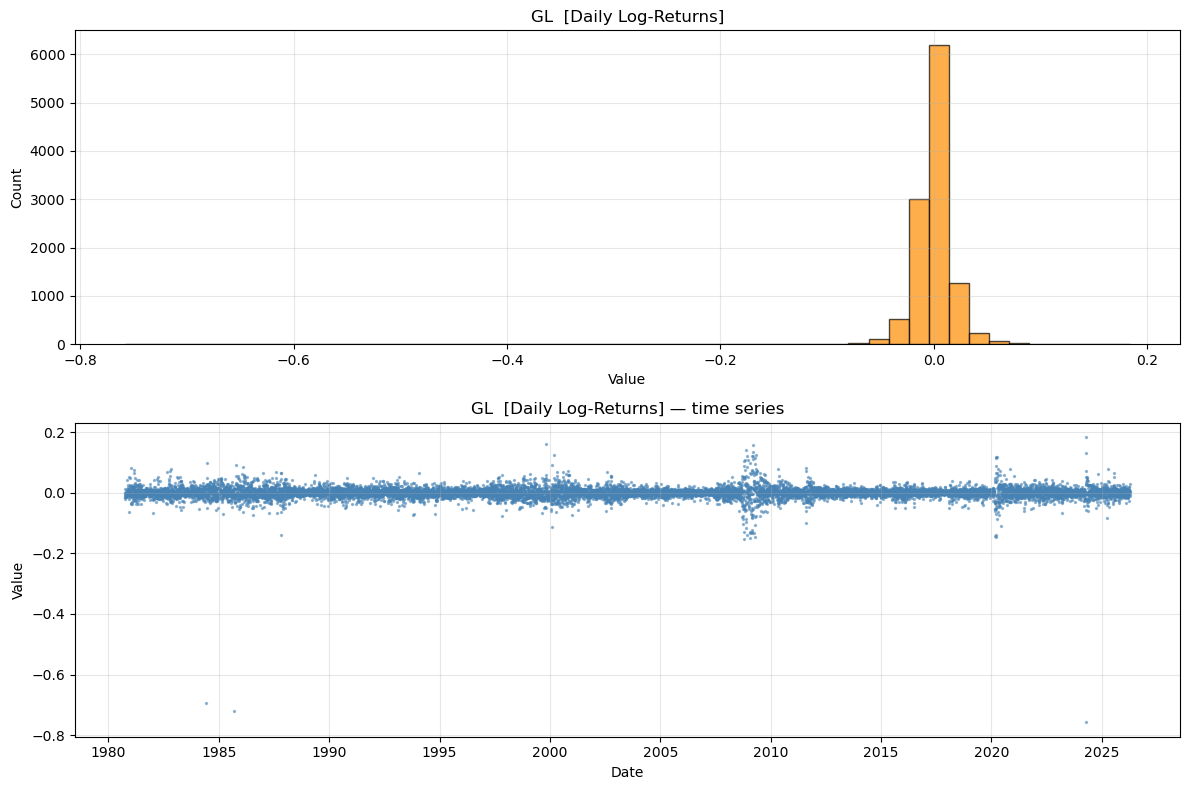


── MNST  [Daily Log-Returns] ──
count       10161.000000
mean            0.000692
std             0.046276
min            -0.693147
25%            -0.009528
50%             0.000000
75%             0.010391
max             0.693147
skewness        0.607248
kurtosis       49.528176


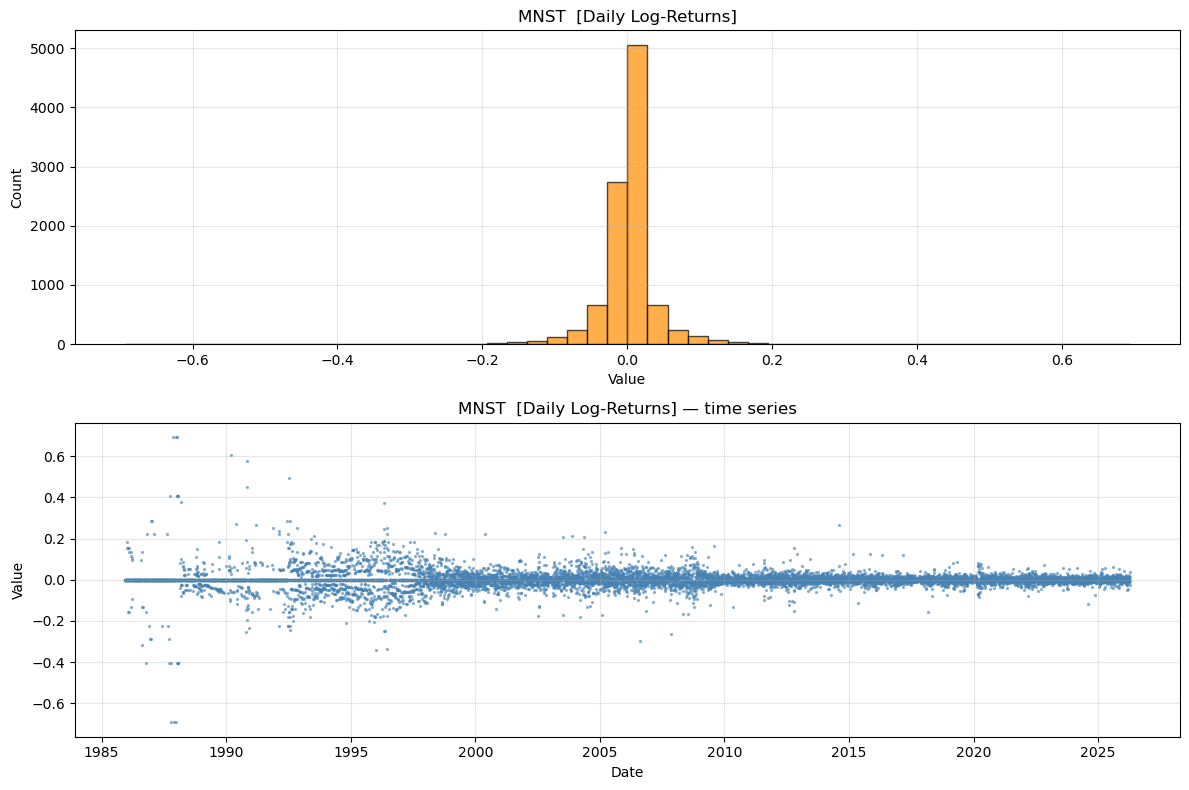


── D  [Daily Log-Returns] ──
count       11610.000000
mean            0.000443
std             0.013272
min            -0.160343
25%            -0.005736
50%             0.000000
75%             0.007053
max             0.382992
skewness        1.512722
kurtosis       71.053941


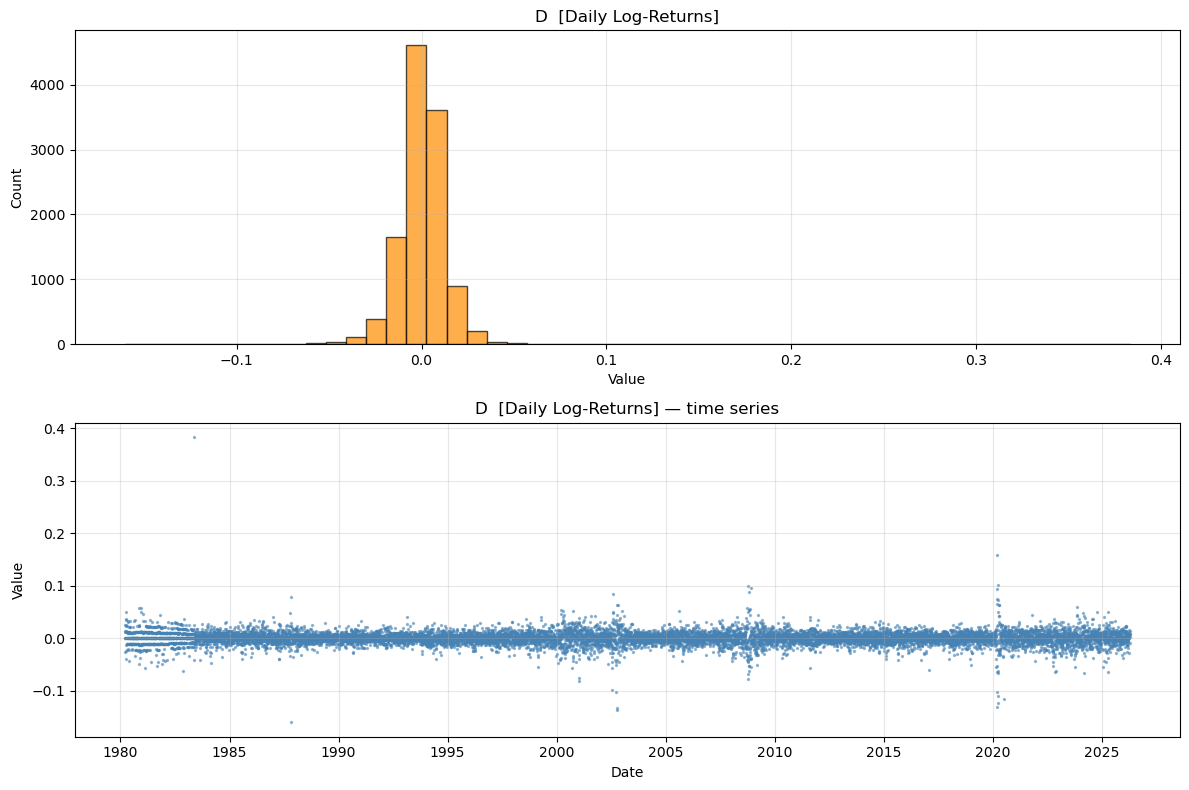


── MRSH  [Daily Log-Returns] ──
count       13396.000000
mean            0.000391
std             0.016900
min            -0.725937
25%            -0.006973
50%             0.000000
75%             0.007815
max             0.134800
skewness       -6.349732
kurtosis      265.751315


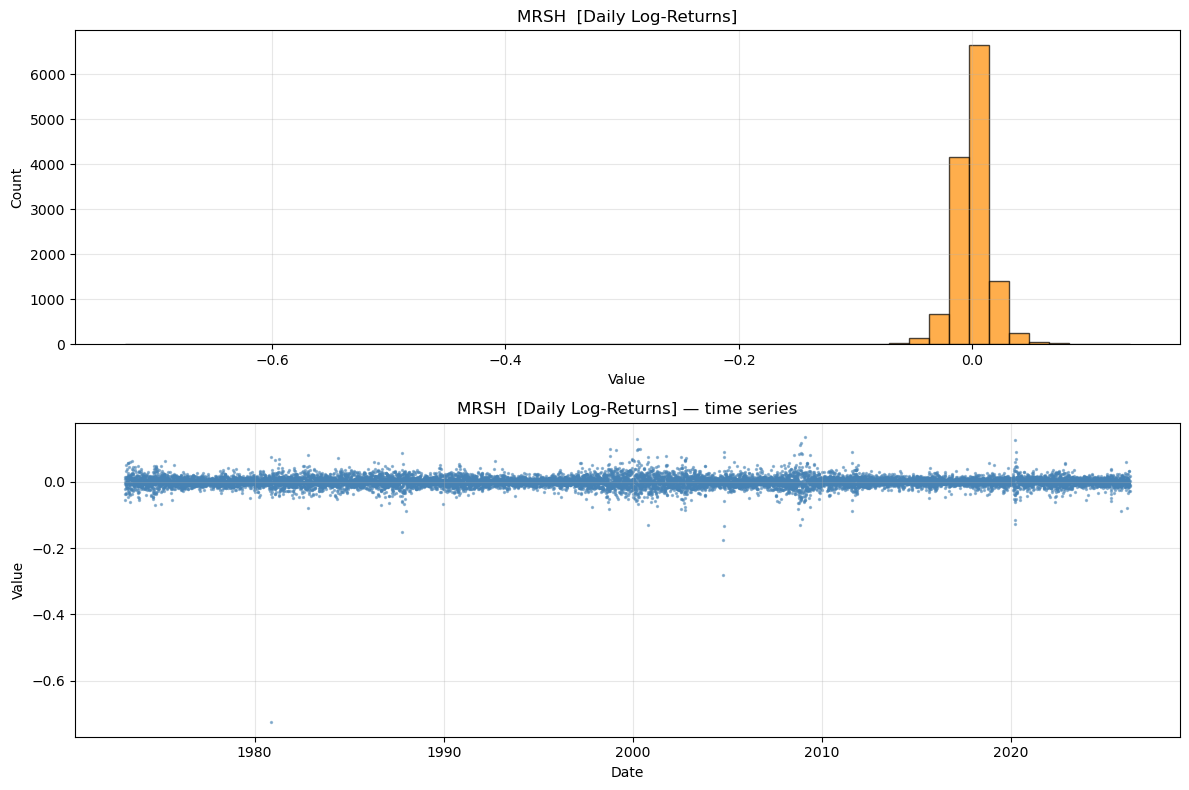


── AIG  [Daily Log-Returns] ──
count       13430.000000
mean            0.000129
std             0.027112
min            -0.936258
25%            -0.008509
50%             0.000000
75%             0.009476
max             0.506818
skewness       -3.509373
kurtosis      168.169536


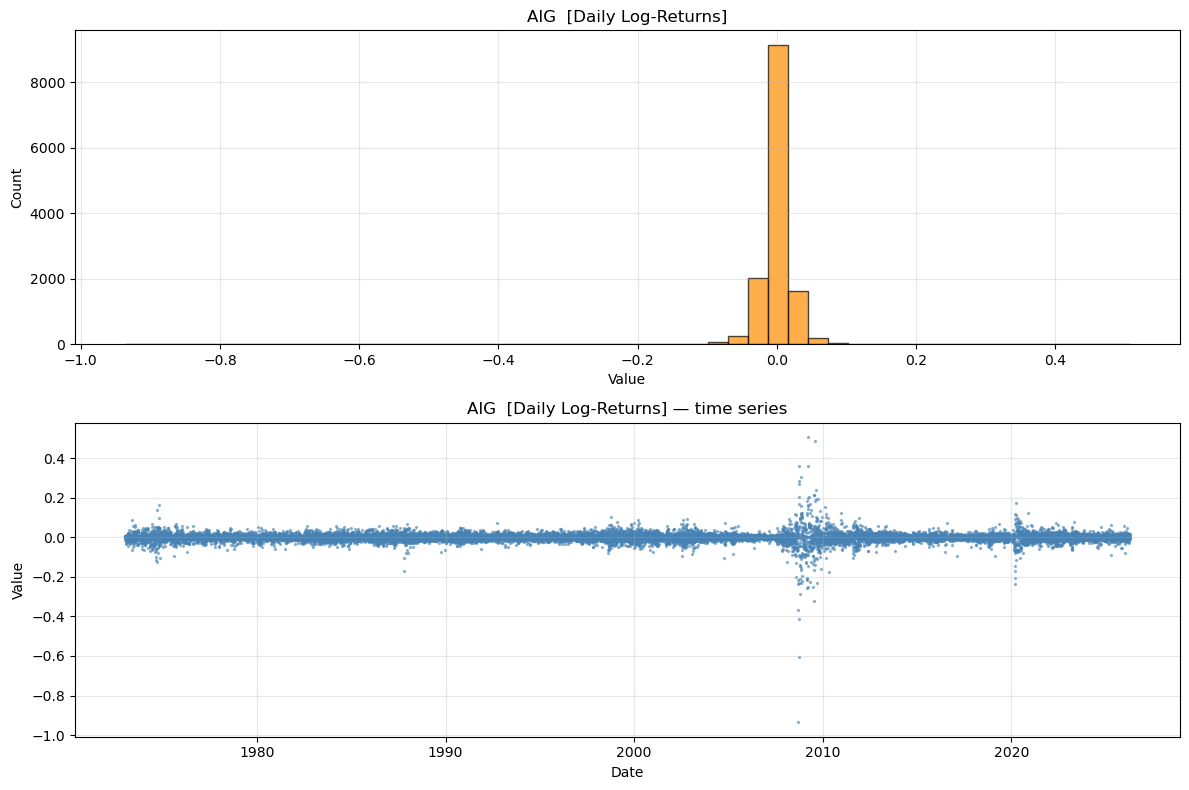

In [32]:
# 3.7  Ticker histograms
tickers_to_plot = ['GL', 'MNST', 'D', 'MRSH', 'AIG']  # ← SET

plot_ticker_histograms(returns_filtered, tickers_to_plot, 'Daily Log-Returns')

# Quantile analysis

In [33]:
# Example call
# _ = compute_trim_counts(raw_clean, percentage=1.0)

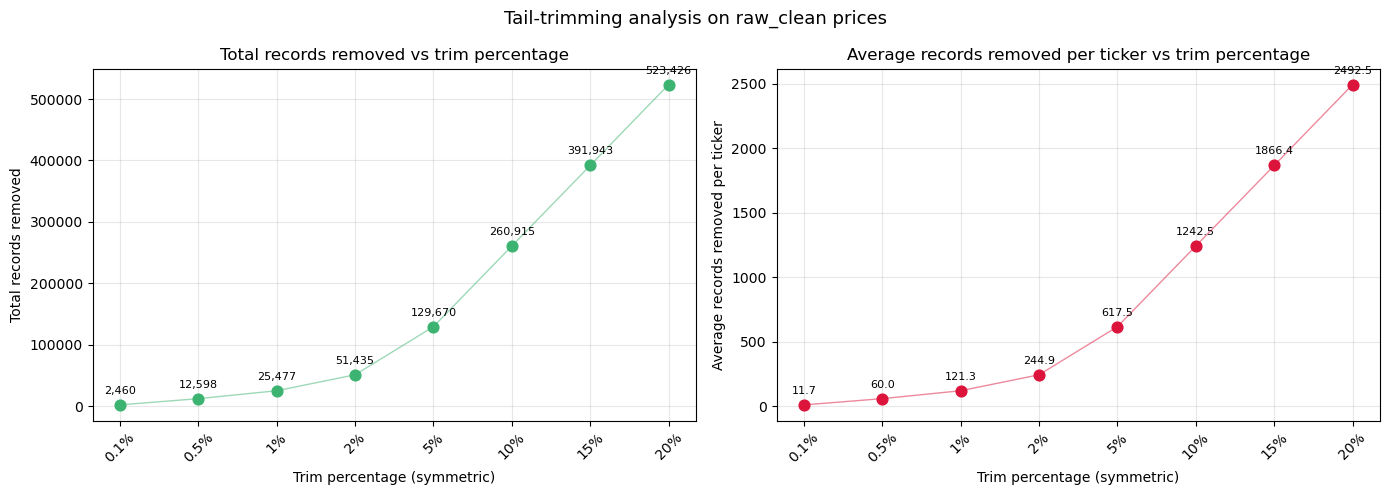

In [34]:
percentages = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

total_removed = []
avg_removed   = []

for pct in percentages:
    lo_q, hi_q = pct / 2, 1.0 - pct / 2
    counts = {}
    for ticker, series in raw_clean.items():
        lo = series.quantile(lo_q)
        hi = series.quantile(hi_q)
        counts[ticker] = int(((series < lo) | (series > hi)).sum())
    s = pd.Series(counts)
    total_removed.append(s.sum())
    avg_removed.append(s.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
pct_labels = [f'{p*100:.3g}%' for p in percentages]

ax1.scatter(range(len(percentages)), total_removed, color='mediumseagreen', s=60, zorder=3)
ax1.plot(range(len(percentages)), total_removed, color='mediumseagreen', alpha=0.5, lw=1)
for i, y in enumerate(total_removed):
    ax1.annotate(f'{y:,}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax1.set_xticks(range(len(percentages)))
ax1.set_xticklabels(pct_labels, rotation=45)
ax1.set_title('Total records removed vs trim percentage')
ax1.set_xlabel('Trim percentage (symmetric)')
ax1.set_ylabel('Total records removed')

ax2.scatter(range(len(percentages)), avg_removed, color='crimson', s=60, zorder=3)
ax2.plot(range(len(percentages)), avg_removed, color='crimson', alpha=0.5, lw=1)
for i, y in enumerate(avg_removed):
    ax2.annotate(f'{y:.1f}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_xticks(range(len(percentages)))
ax2.set_xticklabels(pct_labels, rotation=45)
ax2.set_title('Average records removed per ticker vs trim percentage')
ax2.set_xlabel('Trim percentage (symmetric)')
ax2.set_ylabel('Average records removed per ticker')

plt.suptitle('Tail-trimming analysis on raw_clean prices', fontsize=13)
plt.tight_layout()
plt.show()


# Zero-returns problems

In [35]:
dup_df_result, top10_dups = compute_consecutive_duplicates(raw_filtered)

Total consecutive duplicates across all tickers : 200,511
Average per ticker                              : 954.81
Average % per ticker                            : 7.6646%

Top 10 tickers by consecutive duplicate count:
      count  total     pct
BRO    2921  11382 25.6633
USB    2797  13347 20.9560
WRB    2680  13227 20.2616
DTE    2504  16176 15.4797
SYY    2442  13344 18.3004
UDR    2291  11611 19.7313
MNST   2167  10162 21.3245
ES     2110  13397 15.7498
FRT    2088  13347 15.6440
PNR    2054  13347 15.3892


## Time concentration of the zeros

Plotting the total number of elements with identical precedent values across time so that we can see whether there is a spatial concentration

Date range: 1962-01-02  →  2026-04-10  (16769 business days)


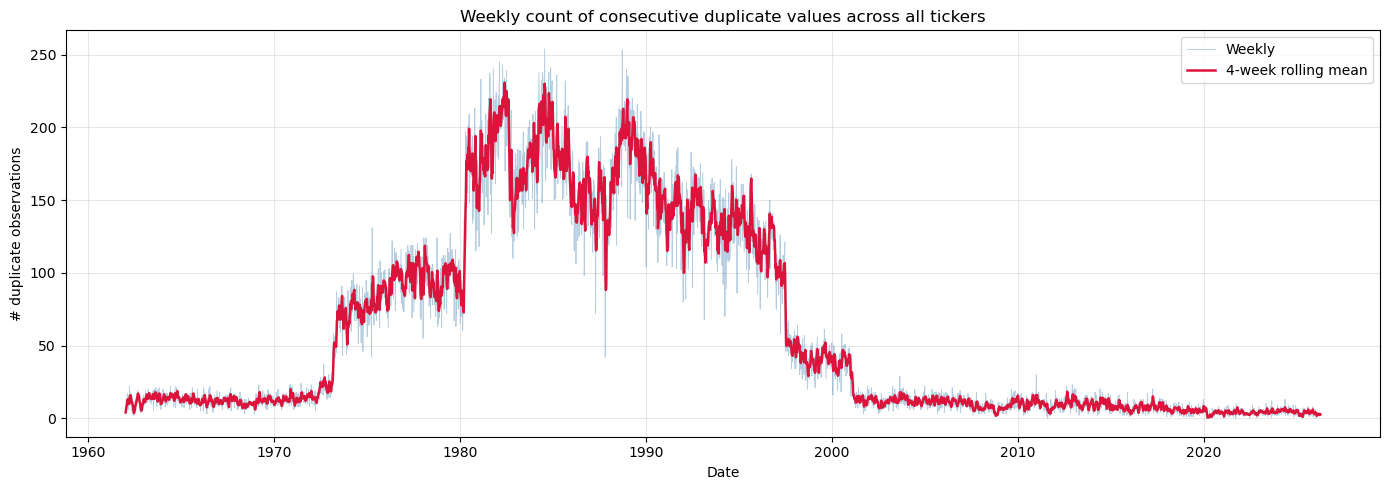

Week with most duplicates: 1984-07-22  (254 duplicates)


In [36]:
# ── find global date range ─────────────────────────────────────────────────
all_dates = pd.date_range(
    start=min(s.index.min() for s in raw_filtered.values()),
    end=max(s.index.max() for s in raw_filtered.values()),
    freq='B'  # business days
)
print(f"Date range: {all_dates[0].date()}  →  {all_dates[-1].date()}  ({len(all_dates)} business days)")

# ── build a DataFrame: one column per ticker, 1 where consecutive duplicate ─
dup_flags = {}
for ticker, series in raw_filtered.items():
    flag = (series == series.shift(1)).astype(int)
    dup_flags[ticker] = flag.reindex(all_dates)  # NaN outside ticker's range

dup_df = pd.DataFrame(dup_flags)

# daily count of tickers showing a consecutive duplicate
daily_dup_count = dup_df.sum(axis=1)

# ── aggregate duplicate counts by week ────────────────────────────────────
weekly_dup_count = daily_dup_count.resample('W').sum()

# ── plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

rolling = weekly_dup_count.rolling(window=4, min_periods=1).mean()

ax.plot(weekly_dup_count.index, weekly_dup_count.values, lw=0.6, alpha=0.4, color='steelblue', label='Weekly')
ax.plot(rolling.index, rolling.values, lw=1.8, color='crimson', label='4-week rolling mean')
ax.set_title('Weekly count of consecutive duplicate values across all tickers')
ax.set_xlabel('Date')
ax.set_ylabel('# duplicate observations')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Week with most duplicates: {weekly_dup_count.idxmax().date()}  ({int(weekly_dup_count.max())} duplicates)")


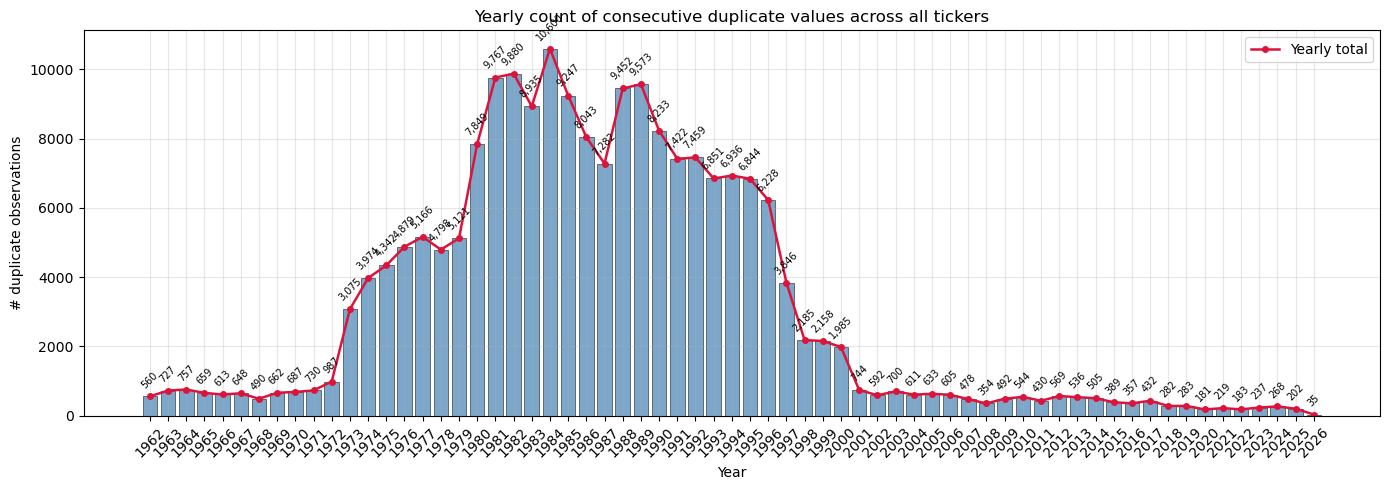


Year with most duplicates : 1984  (10,600)
Year with least duplicates: 2026  (35)


In [37]:
# ── aggregate by year ──────────────────────────────────────────────────────
yearly_dup_count = daily_dup_count.resample('YE').sum()
yearly_dup_count.index = yearly_dup_count.index.year  # use plain year integers as labels

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(yearly_dup_count.index, yearly_dup_count.values, color='steelblue', alpha=0.7, edgecolor='black', lw=0.5)
ax.plot(yearly_dup_count.index, yearly_dup_count.values, color='crimson', lw=1.8, marker='o', ms=4, label='Yearly total')

for x, y in zip(yearly_dup_count.index, yearly_dup_count.values):
    ax.annotate(f'{int(y):,}', (x, y), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=7, rotation=45)

ax.set_title('Yearly count of consecutive duplicate values across all tickers')
ax.set_xlabel('Year')
ax.set_ylabel('# duplicate observations')
ax.set_xticks(yearly_dup_count.index)
ax.set_xticklabels(yearly_dup_count.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nYear with most duplicates : {yearly_dup_count.idxmax()}  ({int(yearly_dup_count.max()):,})")
print(f"Year with least duplicates: {yearly_dup_count.idxmin()}  ({int(yearly_dup_count.min()):,})")


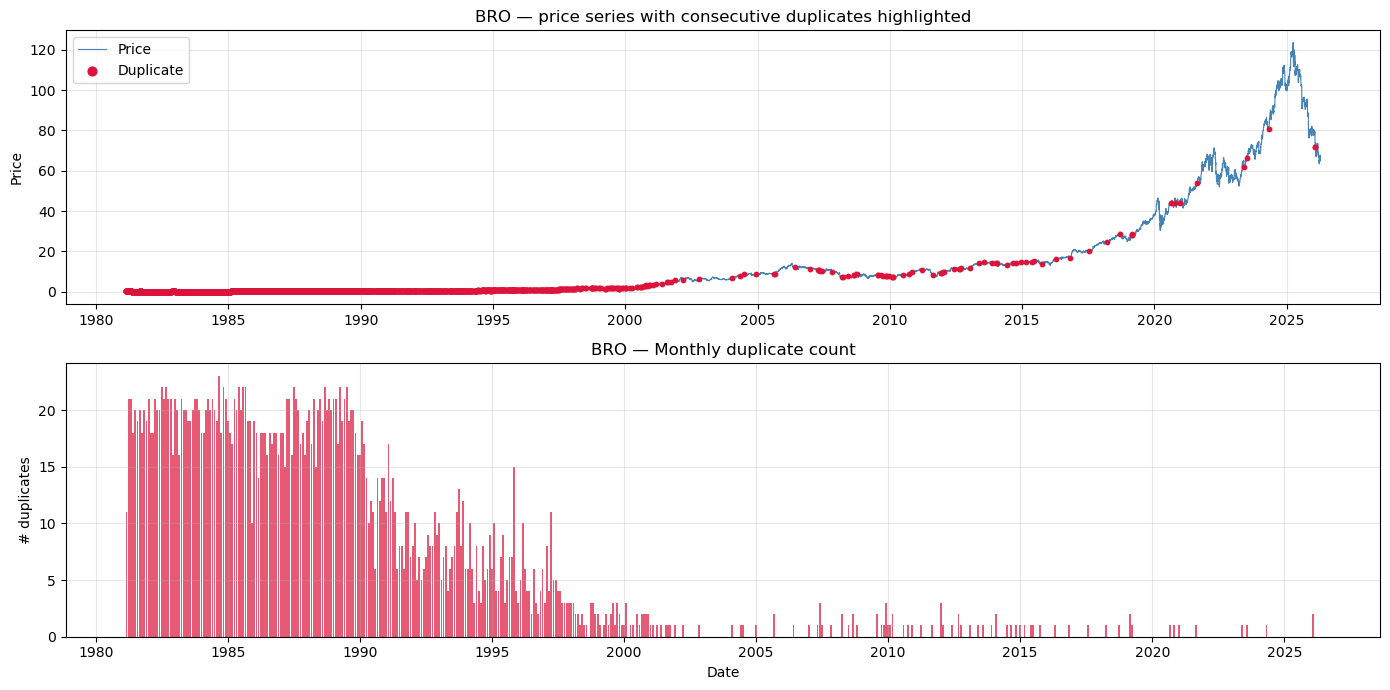


BRO  |  total duplicates: 2921  (25.663% of 11382 obs)
First duplicate : 1981-02-12
Last duplicate  : 2026-01-30


In [38]:
# ── usage ──────────────────────────────────────────────────────────────────
plot_ticker_duplicate_timeline(raw_filtered, 'BRO', freq='ME') #freq for granularity, can set to: 'W', 'ME','YE'

In [39]:
# ── total consecutive duplicates grouped by year and decade ────────────────

daily_totals = dup_df.sum(axis=1).rename('duplicates')
daily_totals.index.name = 'date'

# total non-NaN observations per day across all tickers
daily_obs = dup_df.notna().sum(axis=1)

by_year   = daily_totals.groupby(daily_totals.index.year).sum().rename_axis('year')
by_decade = daily_totals.groupby((daily_totals.index.year // 10) * 10).sum().rename_axis('decade_start')

obs_by_year   = daily_obs.groupby(daily_obs.index.year).sum().rename_axis('year')
obs_by_decade = daily_obs.groupby((daily_obs.index.year // 10) * 10).sum().rename_axis('decade_start')

# ── top 10 ─────────────────────────────────────────────────────────────────
top10_year   = by_year.sort_values(ascending=False).head(10)
top10_decade = by_decade.sort_values(ascending=False).head(10)

print("=" * 55)
print("Top 10 years by consecutive duplicates")
print("=" * 55)
print(f"  {'Year':<8} {'Duplicates':>12} {'Total obs':>12} {'Pct':>8}")
print("-" * 55)
for year, dups in top10_year.items():
    obs = obs_by_year.get(year, 0)
    pct = dups / obs * 100 if obs > 0 else 0
    print(f"  {year:<8} {int(dups):>12,} {int(obs):>12,} {pct:>7.3f}%")

print("\n" + "=" * 55)
print("Top 10 decades by consecutive duplicates")
print("=" * 55)
print(f"  {'Decade':<8} {'Duplicates':>12} {'Total obs':>12} {'Pct':>8}")
print("-" * 55)
for decade, dups in top10_decade.items():
    obs = obs_by_decade.get(decade, 0)
    pct = dups / obs * 100 if obs > 0 else 0
    print(f"  {decade}s{'':<5} {int(dups):>12,} {int(obs):>12,} {pct:>7.3f}%")


Top 10 years by consecutive duplicates
  Year       Duplicates    Total obs      Pct
-------------------------------------------------------
  1984           10,600       49,593  21.374%
  1982            9,880       45,375  21.774%
  1981            9,767       41,966  23.274%
  1989            9,573       52,920  18.090%
  1988            9,452       53,130  17.790%
  1985            9,247       51,116  18.090%
  1983            8,935       46,652  19.152%
  1990            8,233       53,130  15.496%
  1986            8,043       52,971  15.184%
  1980            7,849       36,676  21.401%

Top 10 decades by consecutive duplicates
  Decade     Duplicates    Total obs      Pct
-------------------------------------------------------
  1980s            90,628      483,529  18.743%
  1990s            58,162      530,880  10.956%
  1970s            33,759      171,357  19.701%
  2000s             7,194      528,150   1.362%
  1960s             5,116       50,464  10.138%
  2010s        


── BRO  [Daily Log-Returns] ──
count       11381.000000
mean            0.000574
std             0.019155
min            -0.393042
25%            -0.004805
50%             0.000000
75%             0.006482
max             0.405465
skewness       -0.096587
kurtosis       42.825754


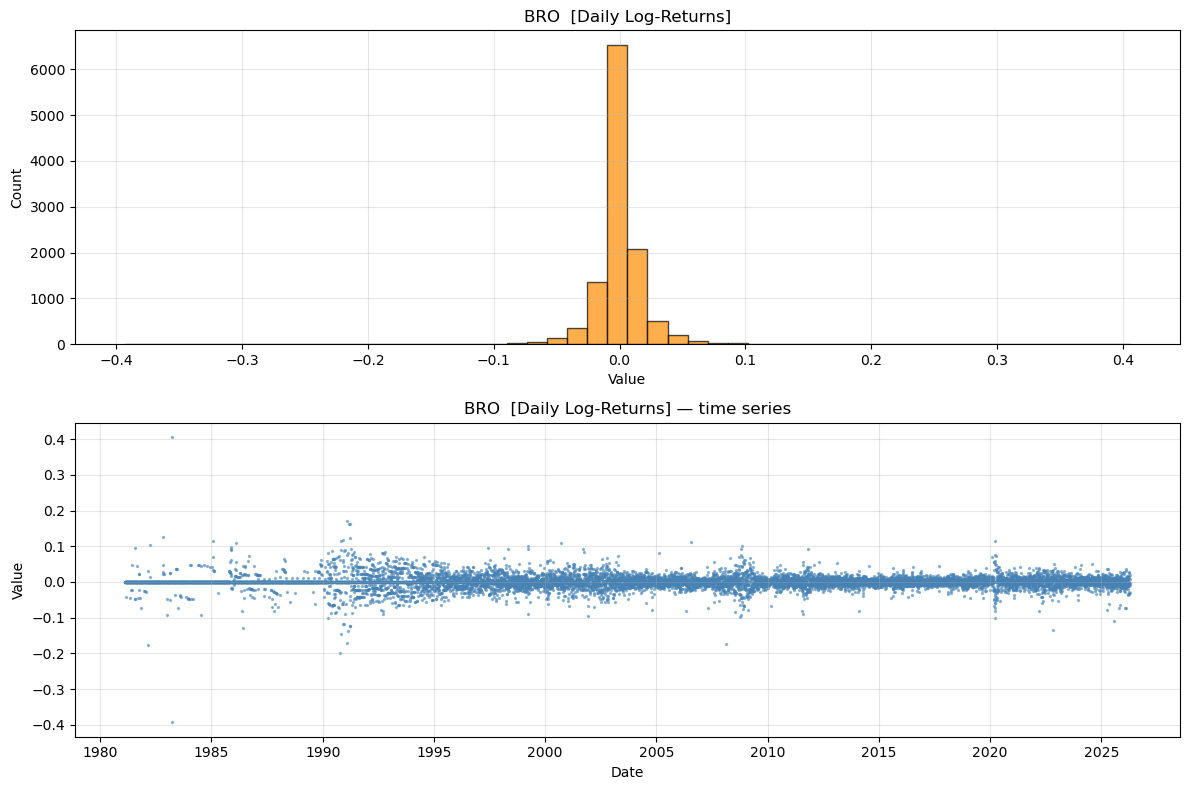


── USB  [Daily Log-Returns] ──
count       13346.000000
mean            0.000449
std             0.018232
min            -0.200469
25%            -0.006416
50%             0.000000
75%             0.007221
max             0.257629
skewness        0.110521
kurtosis       17.652814


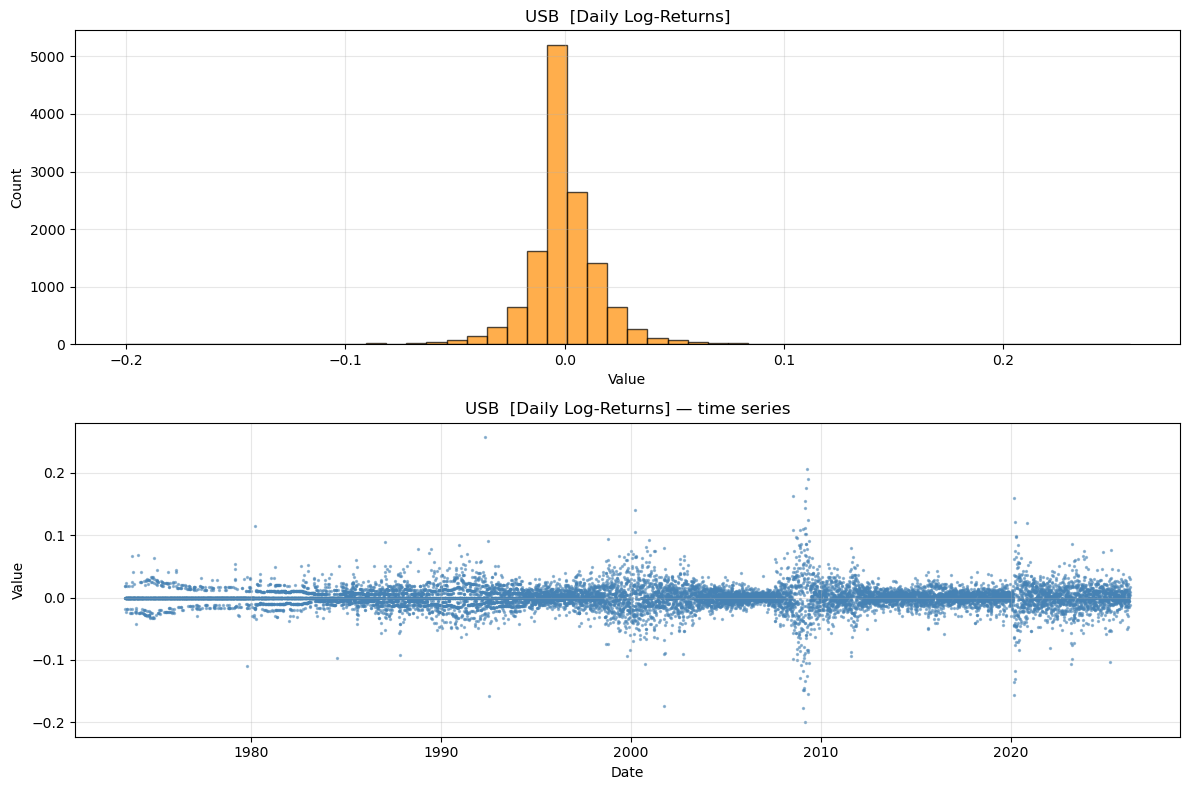


── WRB  [Daily Log-Returns] ──
count       13226.000000
mean            0.000502
std             0.019754
min            -0.302281
25%            -0.006735
50%             0.000000
75%             0.007458
max             0.236395
skewness        0.103371
kurtosis       17.498645


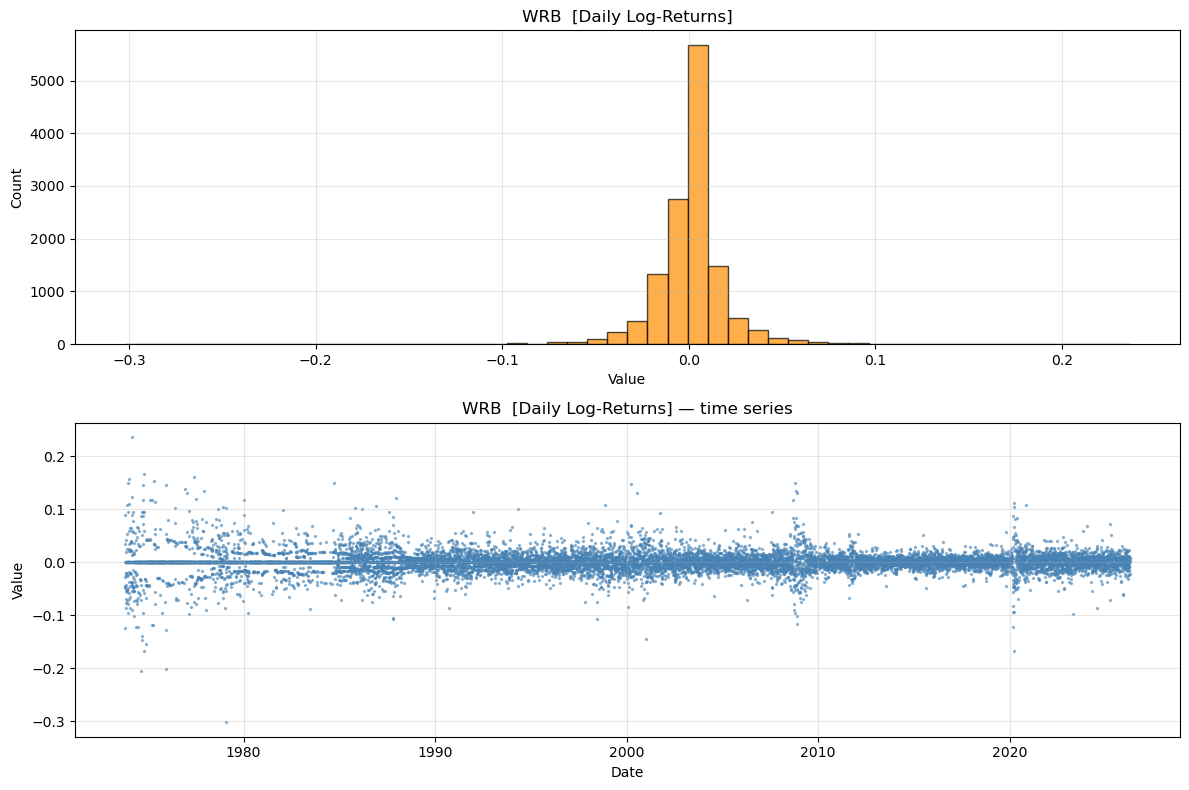

In [40]:
tickers_to_plot = ['BRO', 'USB', 'WRB']

plot_ticker_histograms(returns_filtered, tickers_to_plot, 'Daily Log-Returns')

## Zeros return overall distribution


Aggregate statistics  [Daily Log-Returns]  (N=2,623,490)
  count       : 2,623,490
  mean        : 0.0004514
  std         : 0.0208665
  min         : -0.936258
  q25         : -0.00862582
  median      : 0
  q75         : 0.00948623
  max         : 0.693147
  skewness    : -0.576997
  kurtosis    : 38.5017


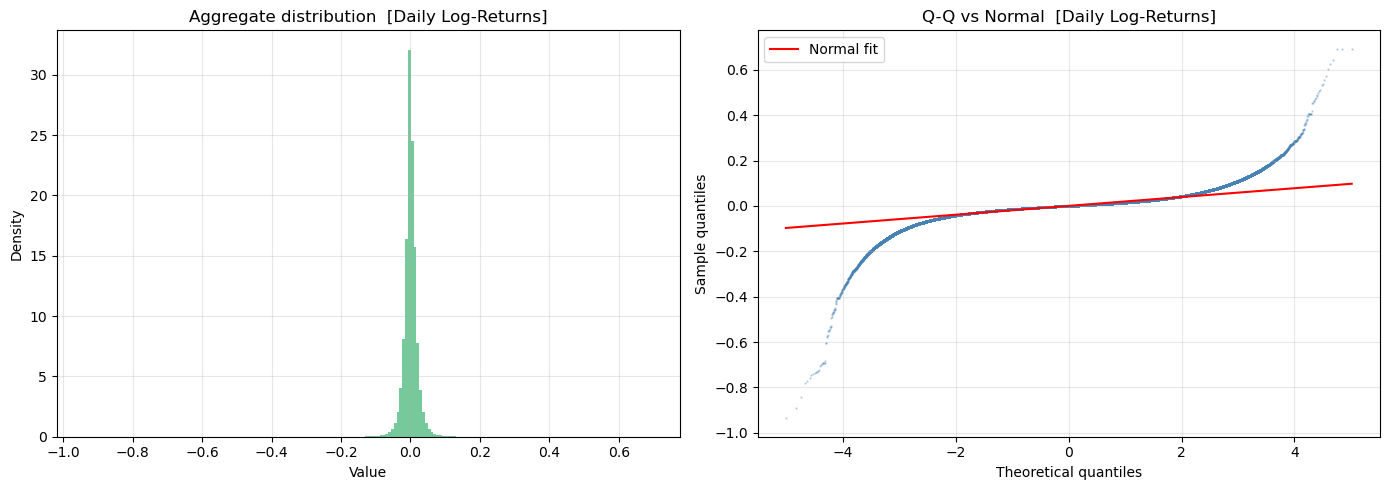

In [41]:
# 3.8  Aggregate statistics + distribution across ALL tickers combined
returns_agg = compute_aggregate_stats_and_plot(returns_filtered, 'Daily Log-Returns')

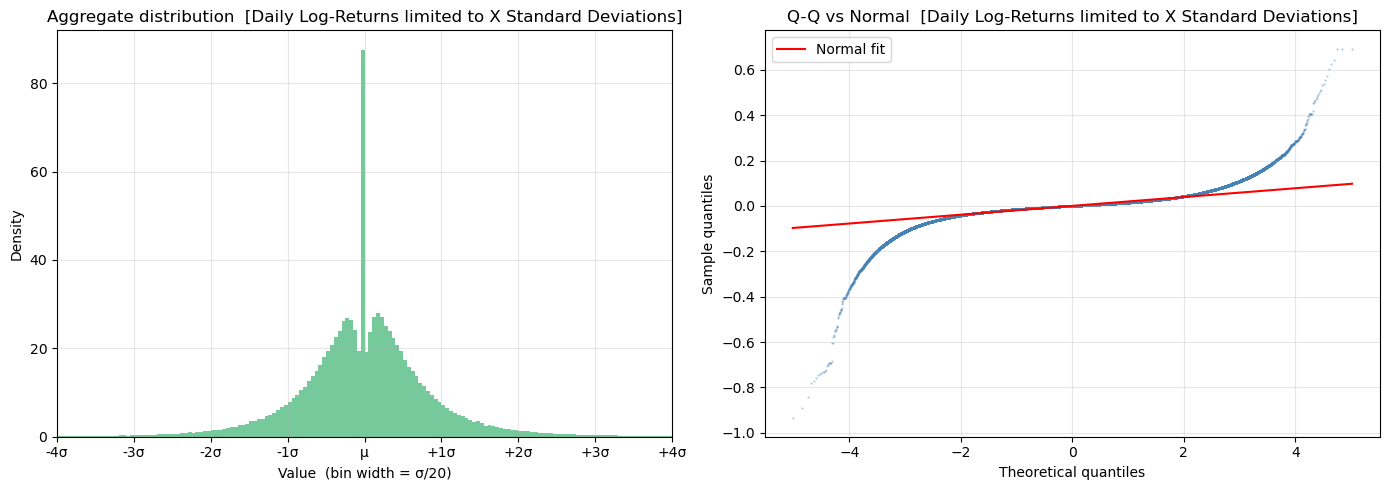

In [42]:
compute_aggregate_stats_and_plot_std(returns_filtered, 'Daily Log-Returns limited to X Standard Deviations', n_stds=4, bins_per_std=20)
print("")

### Plot log-returns distribution by decade


Decade: 1960s  |  tickers: 26  |  total obs: 50,438


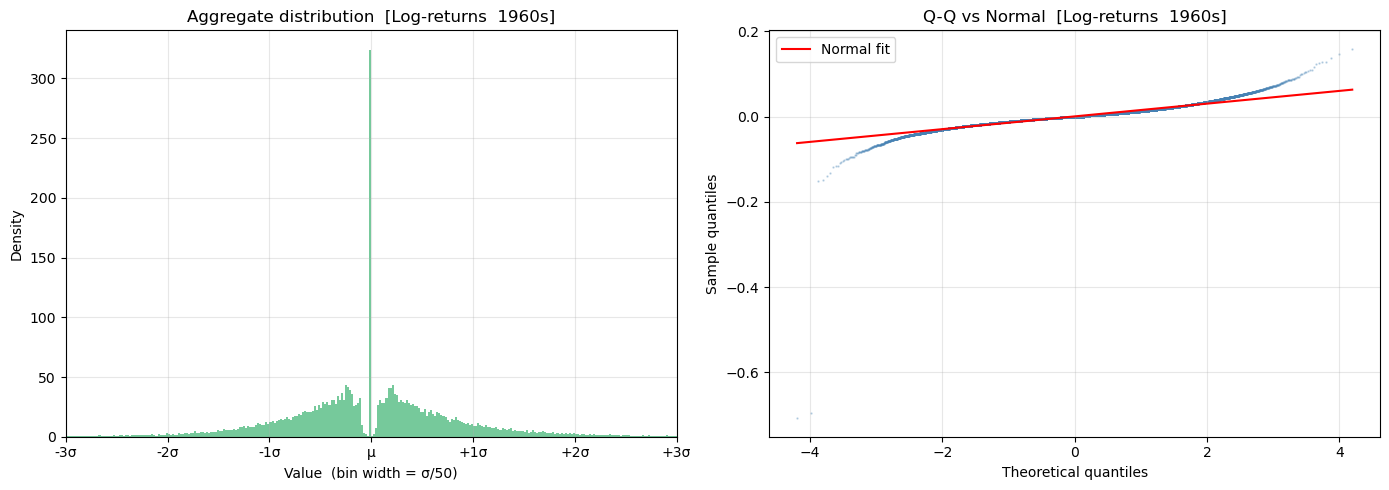


Decade: 1970s  |  tickers: 91  |  total obs: 171,292


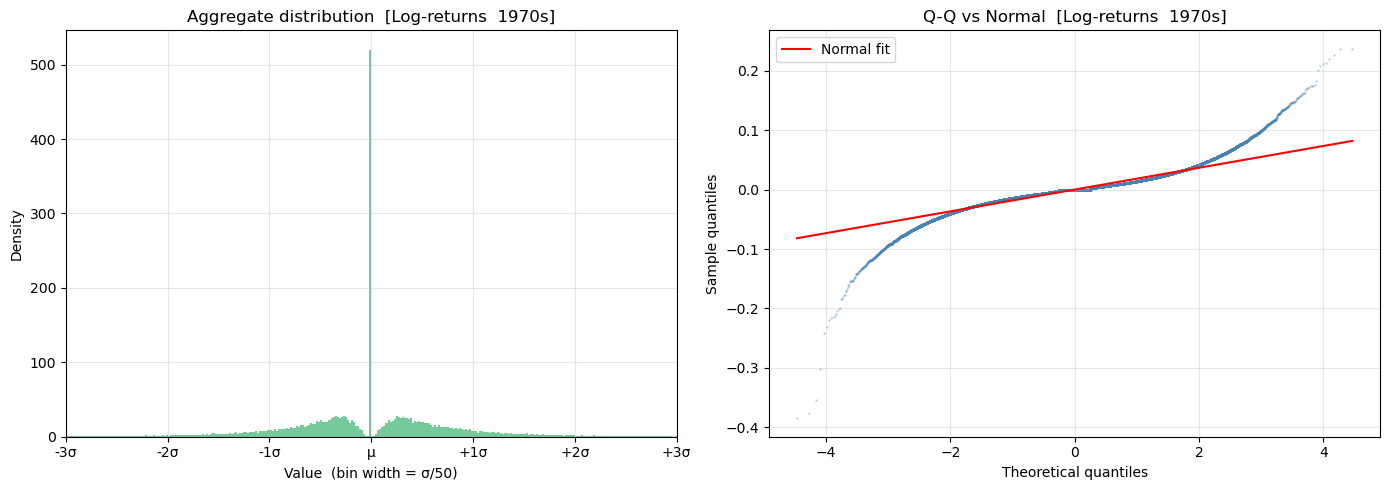


Decade: 1980s  |  tickers: 210  |  total obs: 483,410


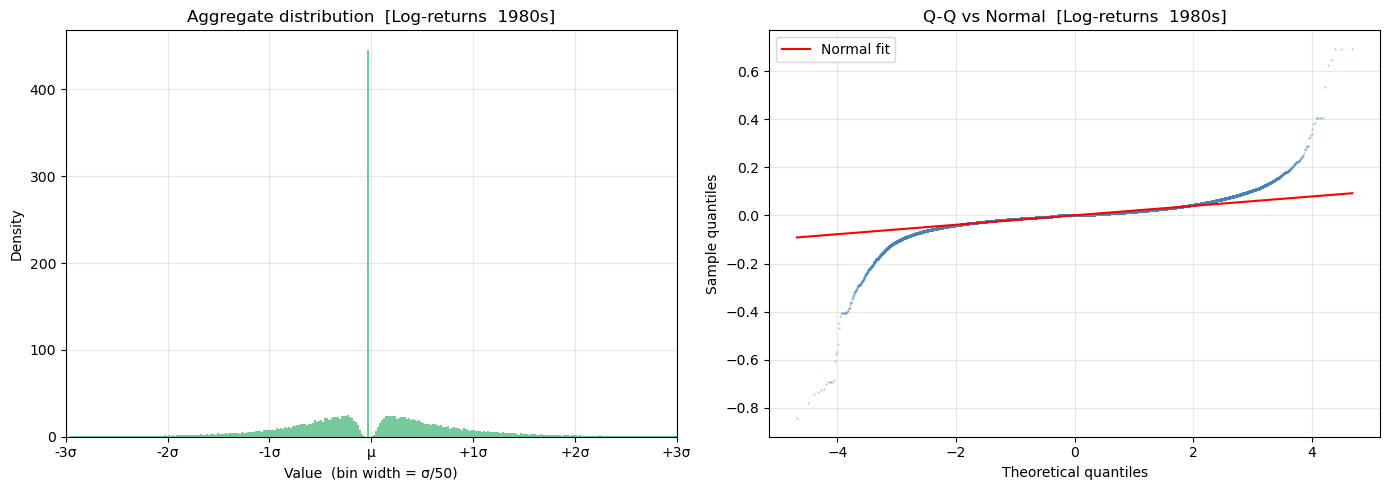


Decade: 1990s  |  tickers: 210  |  total obs: 530,880


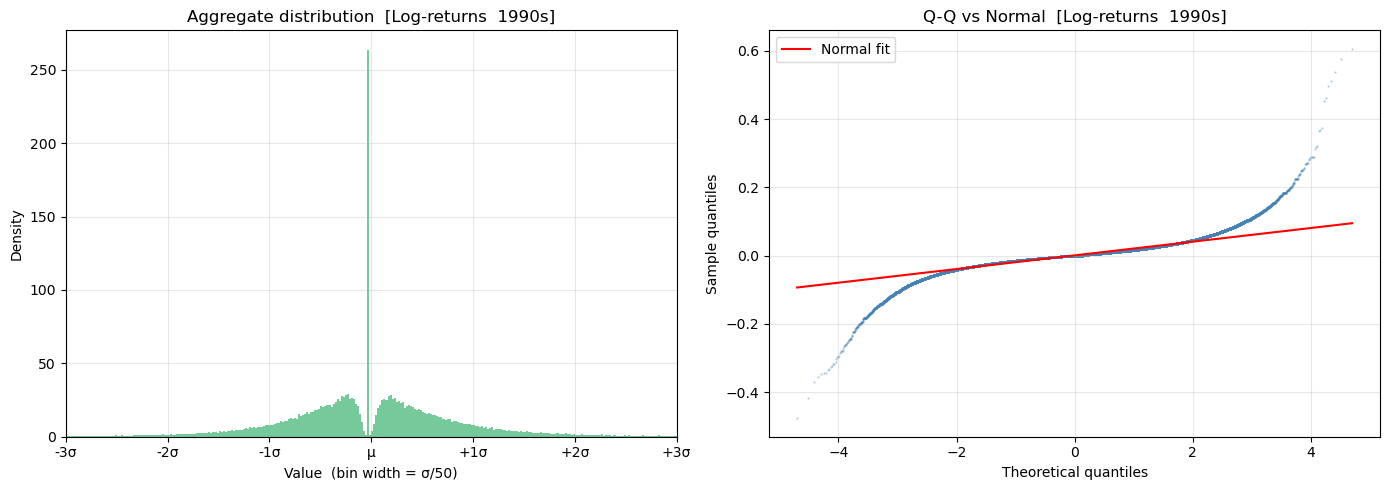


Decade: 2000s  |  tickers: 210  |  total obs: 528,150


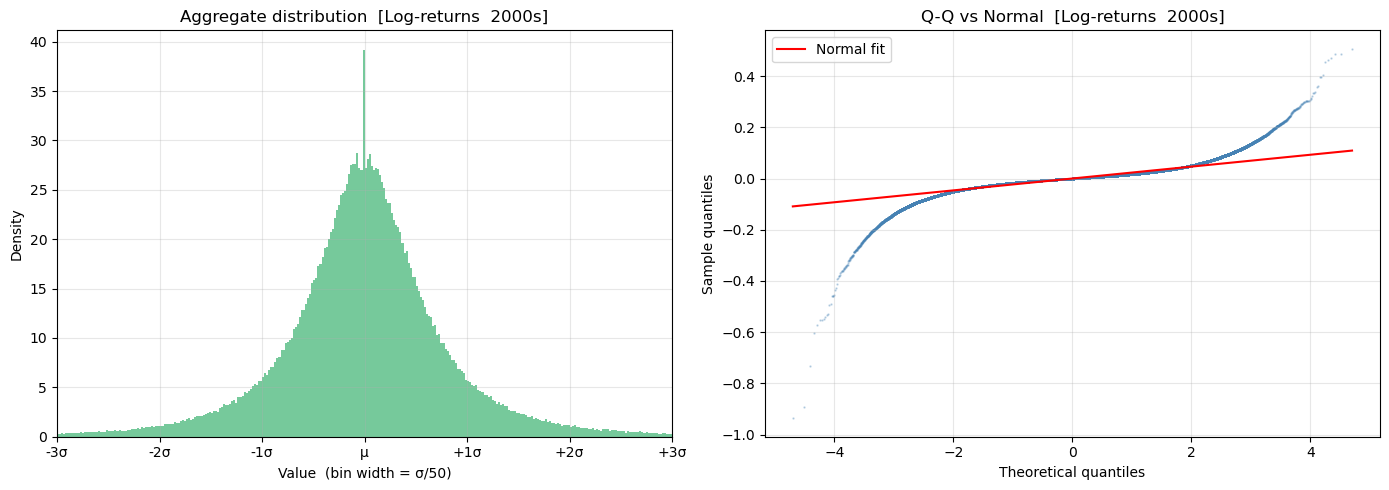


Decade: 2010s  |  tickers: 210  |  total obs: 528,360


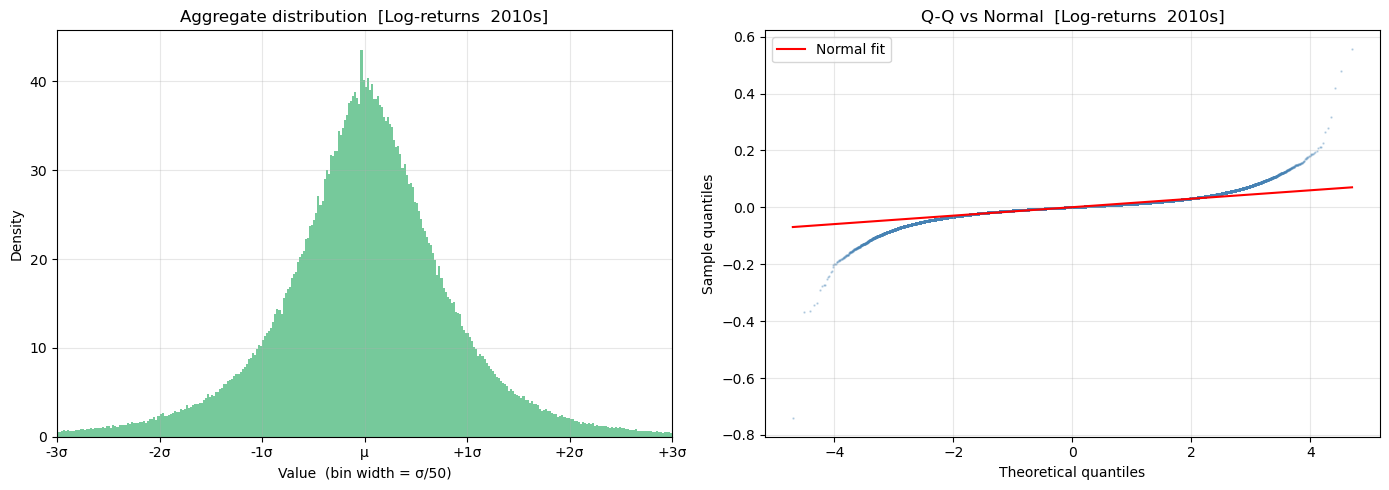


Decade: 2020s  |  tickers: 210  |  total obs: 330,960


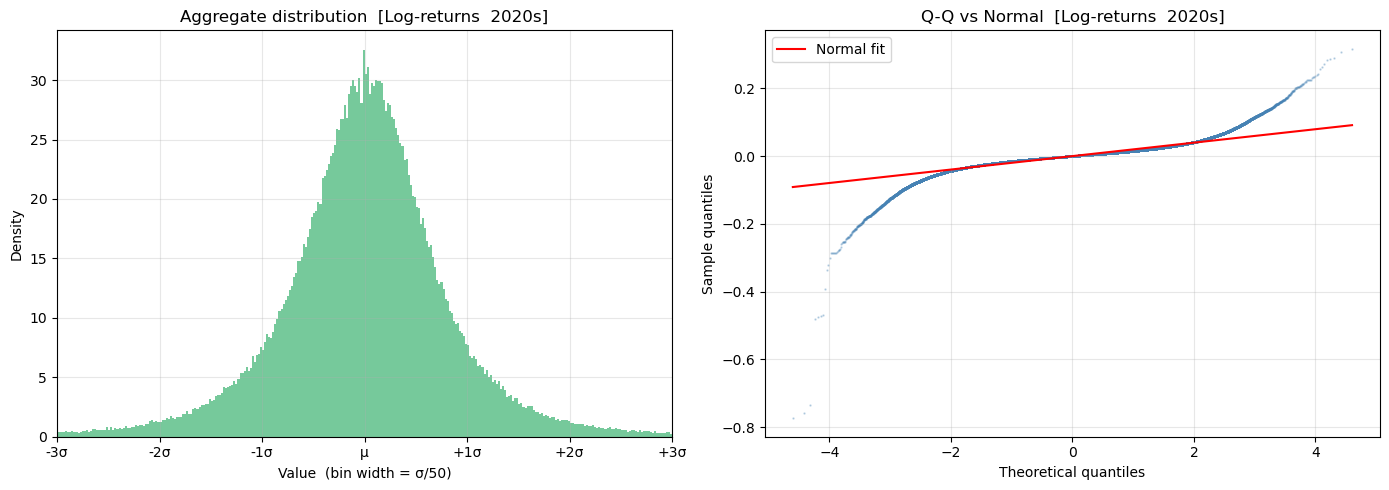

In [43]:
# ── split by decade and run aggregate stats ────────────────────────────────
decades = range(1960, 2030, 10)  # 1990s, 2000s, 2010s, 2020s

for decade_start in decades:
    decade_end = decade_start + 9

    # keep only observations falling within this decade for each ticker
    decade_slice = {
        ticker: series.loc[f'{decade_start}':f'{decade_end}']
        for ticker, series in returns_filtered.items()
    }

    # drop tickers with no data in this decade
    decade_slice = {t: s for t, s in decade_slice.items() if len(s) > 0}

    if not decade_slice:
        print(f"\n{decade_start}s — no data, skipping.")
        continue

    n_obs = sum(len(s) for s in decade_slice.values())
    print(f"\n{'='*60}")
    print(f"Decade: {decade_start}s  |  tickers: {len(decade_slice)}  |  total obs: {n_obs:,}")
    print(f"{'='*60}")

    compute_aggregate_stats_and_plot_std(
        decade_slice,
        label=f'Log-returns  {decade_start}s',
        n_stds=3,
        bins_per_std=50,
    )


Zero log-return rate
  Pre-decimalization  (< 2000-08-28) : 15.416%
  Post-decimalization (> 2001-04-09)   : 0.802%


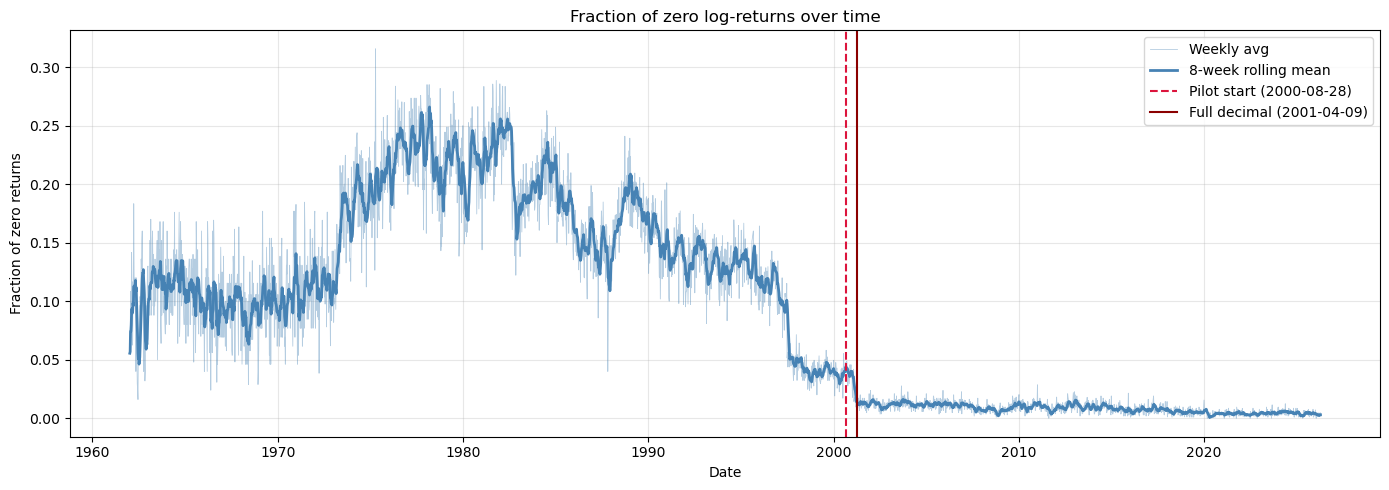

In [44]:
import matplotlib.ticker as mticker

DECIMALIZATION = pd.Timestamp('2000-08-28')  # pilot start
FULL_DECIMAL   = pd.Timestamp('2001-04-09')  # NYSE fully decimal

# ── 1. ZERO LOG-RETURN RATE — before vs after ──────────────────────────────
pre_rates, post_rates = [], []
for series in returns_filtered.values():
    pre  = series.loc[:DECIMALIZATION]
    post = series.loc[FULL_DECIMAL:]
    if len(pre)  > 30: pre_rates.append( (pre  == 0).mean())
    if len(post) > 30: post_rates.append((post == 0).mean())

print("Zero log-return rate")
print(f"  Pre-decimalization  (< {DECIMALIZATION.date()}) : {np.mean(pre_rates)*100:.3f}%")
print(f"  Post-decimalization (> {FULL_DECIMAL.date()})   : {np.mean(post_rates)*100:.3f}%")

# ── 4. ROLLING ZERO-RETURN RATE OVER TIME with decimalization markers ───────
all_returns = pd.concat(returns_filtered.values()).sort_index()
daily_zero_rate = all_returns.groupby(all_returns.index).apply(lambda x: (x == 0).mean())
weekly_zero_rate = daily_zero_rate.resample('W').mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_zero_rate.index, weekly_zero_rate.values,
        lw=0.6, alpha=0.4, color='steelblue', label='Weekly avg')
ax.plot(weekly_zero_rate.index,
        weekly_zero_rate.rolling(8, min_periods=1).mean().values,
        lw=2, color='steelblue', label='8-week rolling mean')
ax.axvline(DECIMALIZATION, color='crimson', lw=1.5, linestyle='--', label='Pilot start (2000-08-28)')
ax.axvline(FULL_DECIMAL,   color='darkred', lw=1.5, linestyle='-',  label='Full decimal (2001-04-09)')
ax.set_title('Fraction of zero log-returns over time')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of zero returns')
ax.legend()
plt.tight_layout()
plt.show()


# Log-return analysis

In [45]:
log_data = load_csvs('../data/log_replication', 'log_adj_close')
log_clean = analyze_nans(log_data)

log_clean.pop('BEN')
log_clean.pop('HUBB')
log_clean.pop('NVR')
log_clean.pop('WMB')

log_stats = compute_all_stats(log_clean)
describe_stats(log_stats, 'Daily Log-Prices')

Loaded 210 tickers from: ..\data\log_replication
No NaN values found in any ticker.
Total NaNs across all tickers: 0


KeyError: 'BEN'

In [ ]:
# 2.6  Quantile filter
quantile_level = 0.9  # ← SET

log_outliers = quantile_filter(log_stats, quantile_level)


90%-quantile thresholds per statistic:
count       16176.000000
mean            2.895405
std             2.290834
min             0.173968
q25             1.735883
median          3.131498
q75             4.371250
max             6.135533
skewness        0.219716
kurtosis       -0.563529

Tickers exceeding at least one 90% threshold: 92
          count    mean     std     min     q25  median     q75     max  skewness  kurtosis
ticker                                                                                     
AAPL    11423.0  0.6756  2.6233 -3.2805 -1.3966 -0.6991  3.0892  5.6557    0.4546   -1.2392
ADSK    10274.0  3.0887  1.5514 -0.8112  1.8314  3.1934  4.0796  5.8356    0.0607   -0.8799
AIG     13431.0  4.2850  1.4390  1.4757  3.2394  3.9375  5.2992  7.1040    0.4546   -0.9052
AJG     10533.0  2.6227  1.5649 -0.5382  1.1860  2.7254  3.6535  5.8446    0.2420   -0.9188
AMD     11611.0  2.5009  1.0928  0.4824  1.7290  2.3646  2.8876  5.5772    0.7901    0.1700
AME     10513.0 


Aggregate statistics  [Daily Log-Price Filtered]  (N=2,623,700)
  count       : 2,623,700
  mean        : 2.10825
  std         : 1.92841
  min         : -6.56385
  q25         : 0.770198
  median      : 2.34791
  q75         : 3.53134
  max         : 7.46008
  skewness    : -0.422589
  kurtosis    : -0.10594


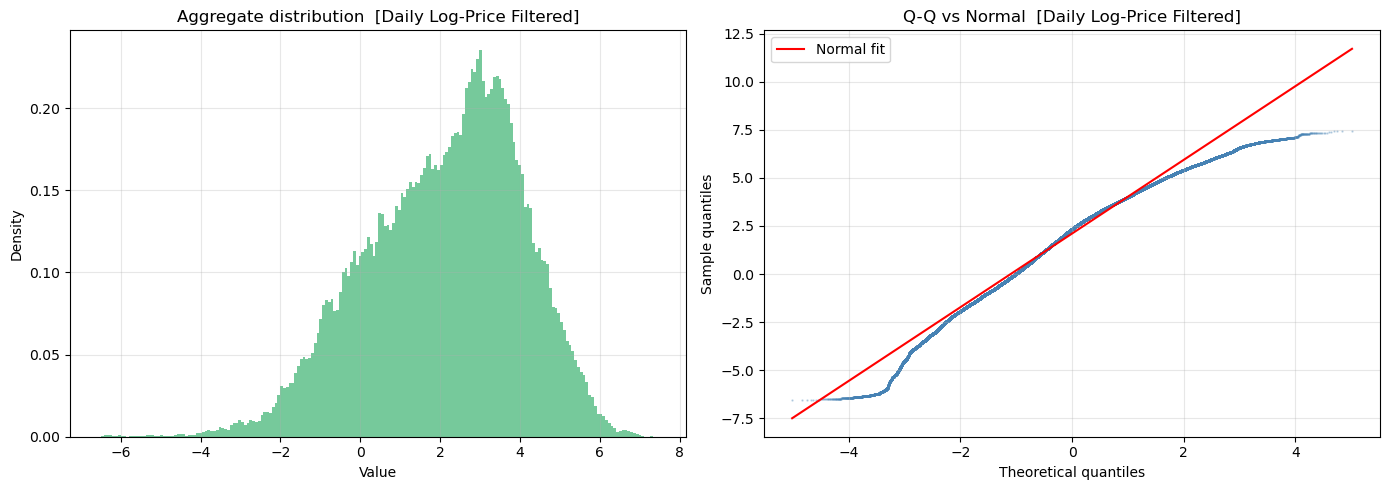

In [ ]:
# 3.8  Aggregate statistics + distribution across ALL tickers combined
returns_agg = compute_aggregate_stats_and_plot(log_clean, 'Daily Log-Price Filtered')

### Plot log-price by decade


Decade: 1960s  |  tickers: 26  |  total obs: 50,464


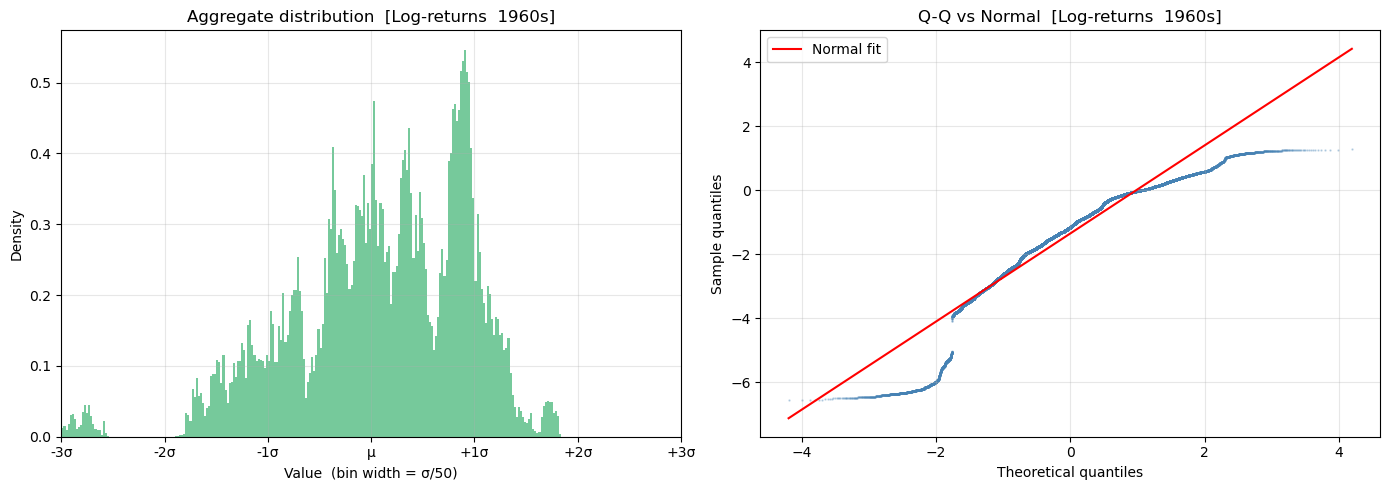


Decade: 1970s  |  tickers: 91  |  total obs: 171,357


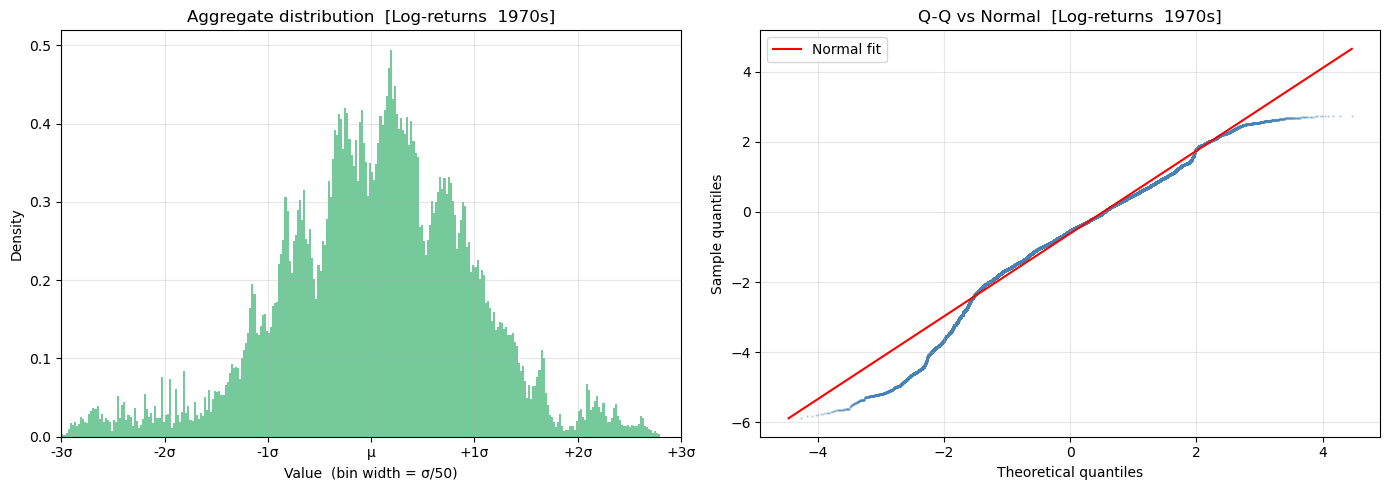


Decade: 1980s  |  tickers: 210  |  total obs: 483,529


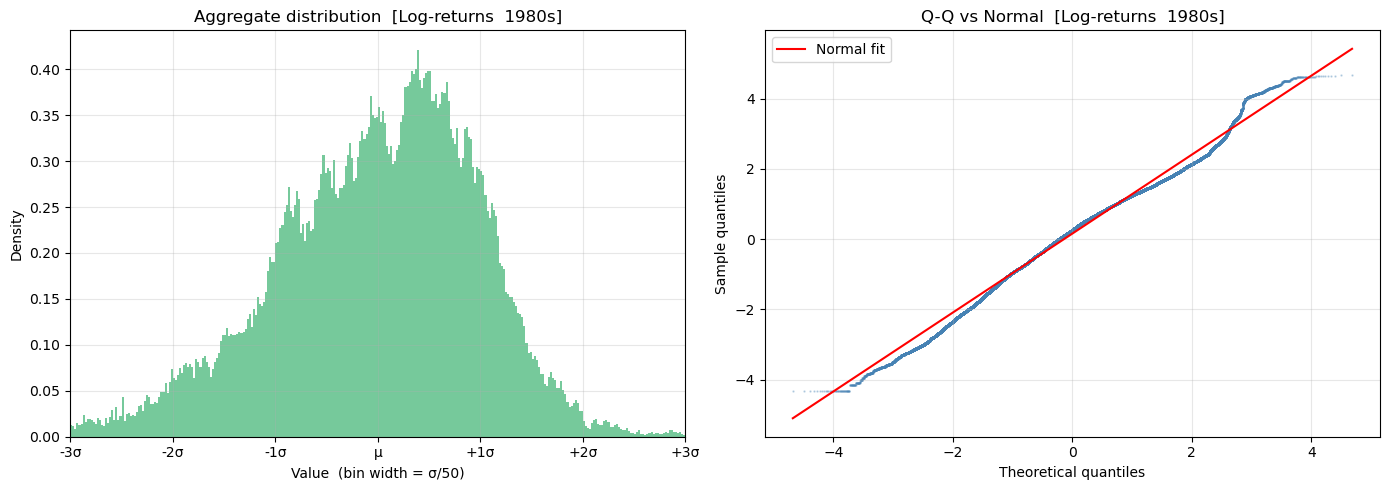


Decade: 1990s  |  tickers: 210  |  total obs: 530,880


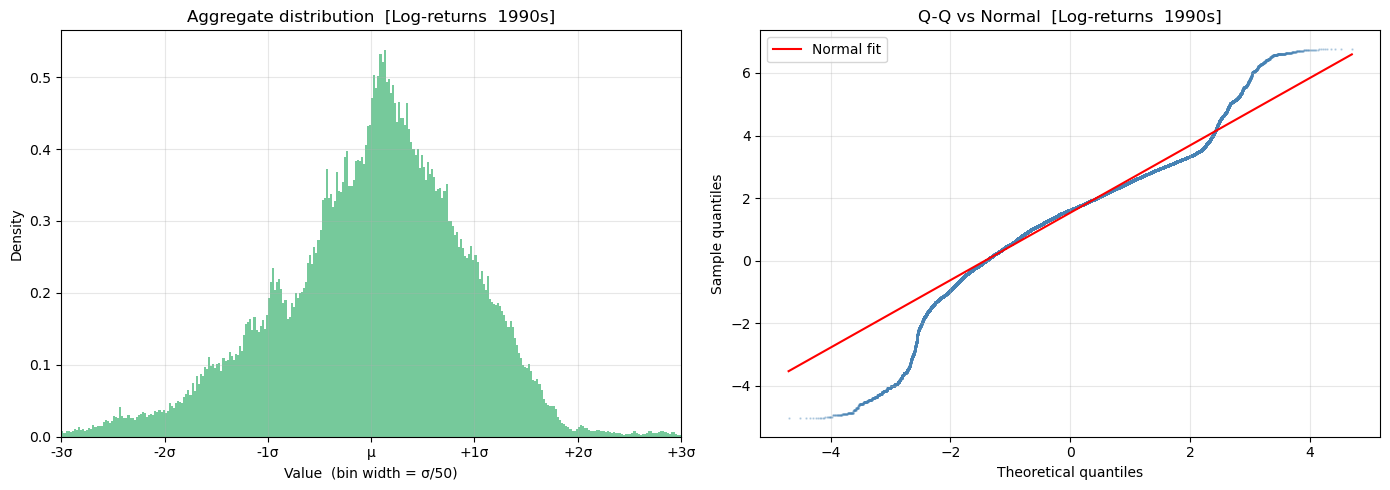


Decade: 2000s  |  tickers: 210  |  total obs: 528,150


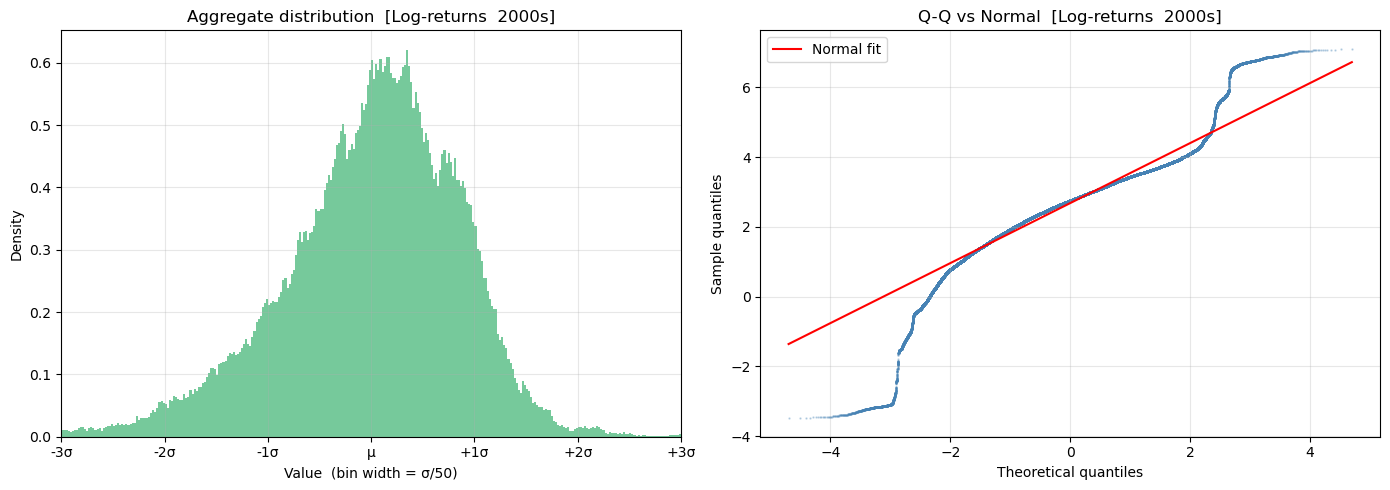


Decade: 2010s  |  tickers: 210  |  total obs: 528,360


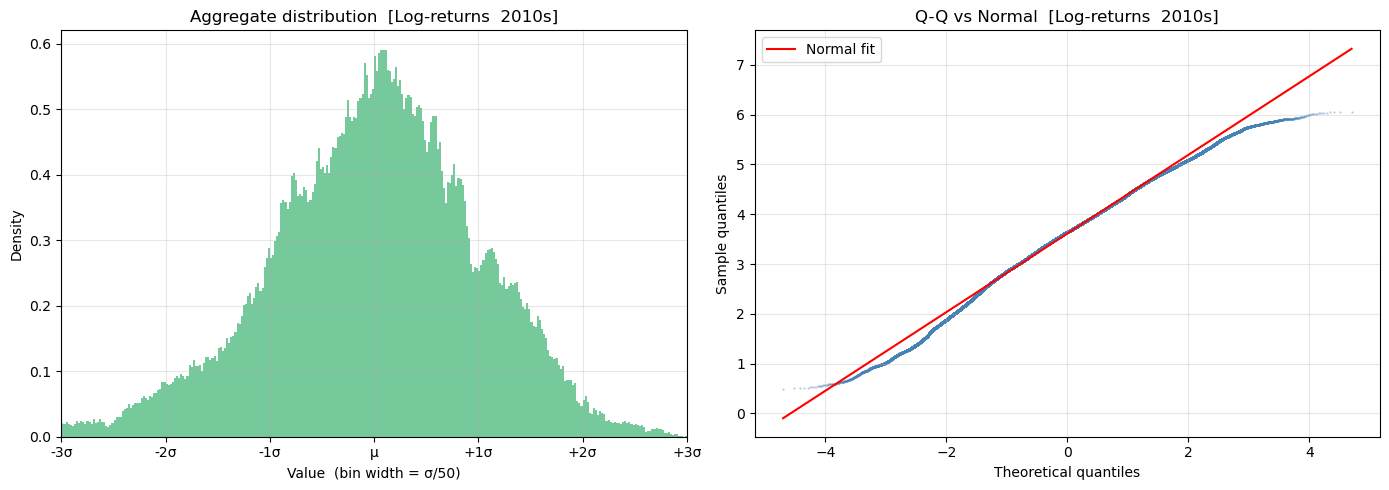


Decade: 2020s  |  tickers: 210  |  total obs: 330,960


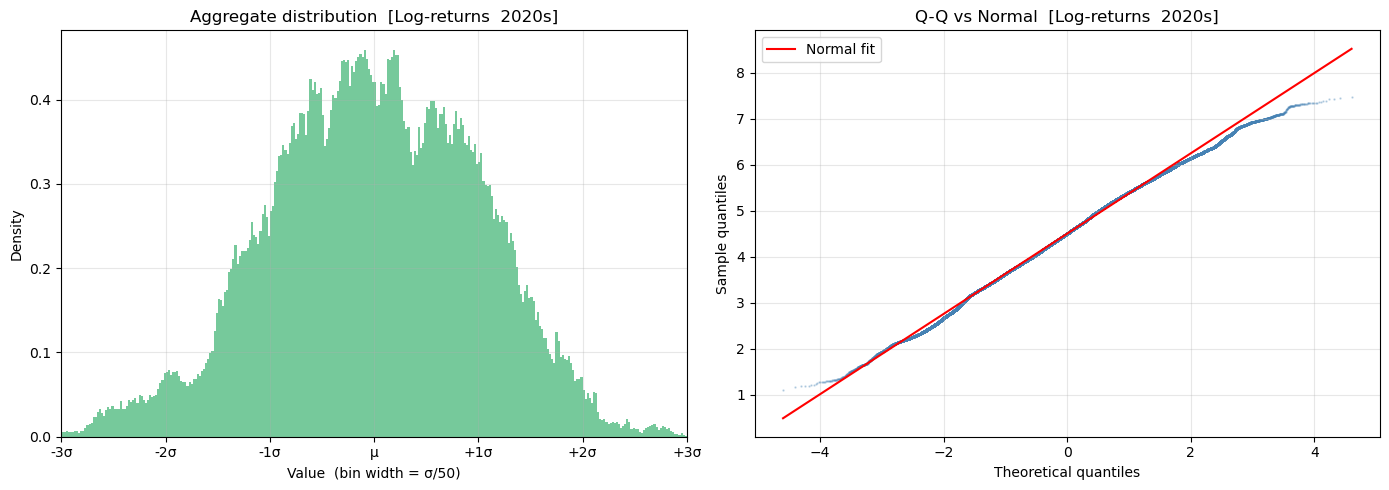

In [ ]:
# ── split by decade and run aggregate stats ────────────────────────────────
decades = range(1960, 2030, 10)  # 1990s, 2000s, 2010s, 2020s

for decade_start in decades:
    decade_end = decade_start + 9

    # keep only observations falling within this decade for each ticker
    decade_slice = {
        ticker: series.loc[f'{decade_start}':f'{decade_end}']
        for ticker, series in log_clean.items()
    }

    # drop tickers with no data in this decade
    decade_slice = {t: s for t, s in decade_slice.items() if len(s) > 0}

    if not decade_slice:
        print(f"\n{decade_start}s — no data, skipping.")
        continue

    n_obs = sum(len(s) for s in decade_slice.values())
    print(f"\n{'='*60}")
    print(f"Decade: {decade_start}s  |  tickers: {len(decade_slice)}  |  total obs: {n_obs:,}")
    print(f"{'='*60}")

    compute_aggregate_stats_and_plot_std(
        decade_slice,
        label=f'Log-returns  {decade_start}s',
        n_stds=3,
        bins_per_std=50,
    )


### Plot the average price by year with confidence

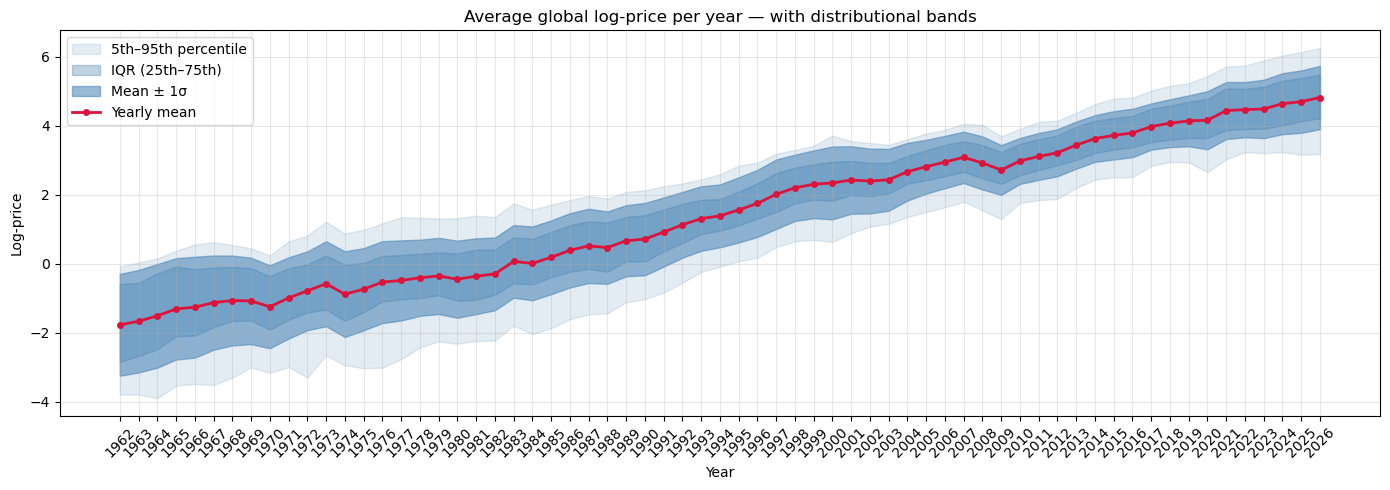

In [ ]:
log_filtered = log_clean.copy()

# ── compute per-year mean and 95% CI across all tickers and observations ───
records = []
for ticker, series in log_filtered.items():
    df = series.rename('log_price').to_frame()
    df['year'] = df.index.year
    records.append(df)

all_log = pd.concat(records)

grouped   = all_log.groupby('year')['log_price']
yearly_mean = grouped.mean()
yearly_std  = grouped.std()
yearly_n    = grouped.count()

# 95% confidence interval: ±1.96 * SE
se     = yearly_std / np.sqrt(yearly_n)
ci_lo  = yearly_mean - 1.96 * se
ci_hi  = yearly_mean + 1.96 * se

# ── plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

yearly_q25   = grouped.quantile(0.25)
yearly_q75   = grouped.quantile(0.75)
yearly_q05   = grouped.quantile(0.05)
yearly_q95   = grouped.quantile(0.95)

# 5th–95th percentile band (wide spread)
ax.fill_between(yearly_mean.index, yearly_q05, yearly_q95,
                alpha=0.15, color='steelblue', label='5th–95th percentile')

# IQR band (central 50%)
ax.fill_between(yearly_mean.index, yearly_q25, yearly_q75,
                alpha=0.35, color='steelblue', label='IQR (25th–75th)')

# mean ± 1 std (cross-sectional dispersion)
ax.fill_between(yearly_mean.index,
                yearly_mean - yearly_std,
                yearly_mean + yearly_std,
                alpha=0.55, color='steelblue', label='Mean ± 1σ')

# mean line
ax.plot(yearly_mean.index, yearly_mean.values,
        color='crimson', lw=2, marker='o', ms=4, label='Yearly mean')

ax.set_title('Average global log-price per year — with distributional bands')
ax.set_xlabel('Year')
ax.set_ylabel('Log-price')
ax.set_xticks(yearly_mean.index)
ax.set_xticklabels(yearly_mean.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


Tickers not found: ['NVR']

── WDC  [log_adj_close] ──
count       11958.000000
mean            2.191572
std             1.298144
min            -0.878556
25%             1.155791
50%             2.026855
75%             3.373013
max             5.838983
skewness        0.087380
kurtosis       -0.997259


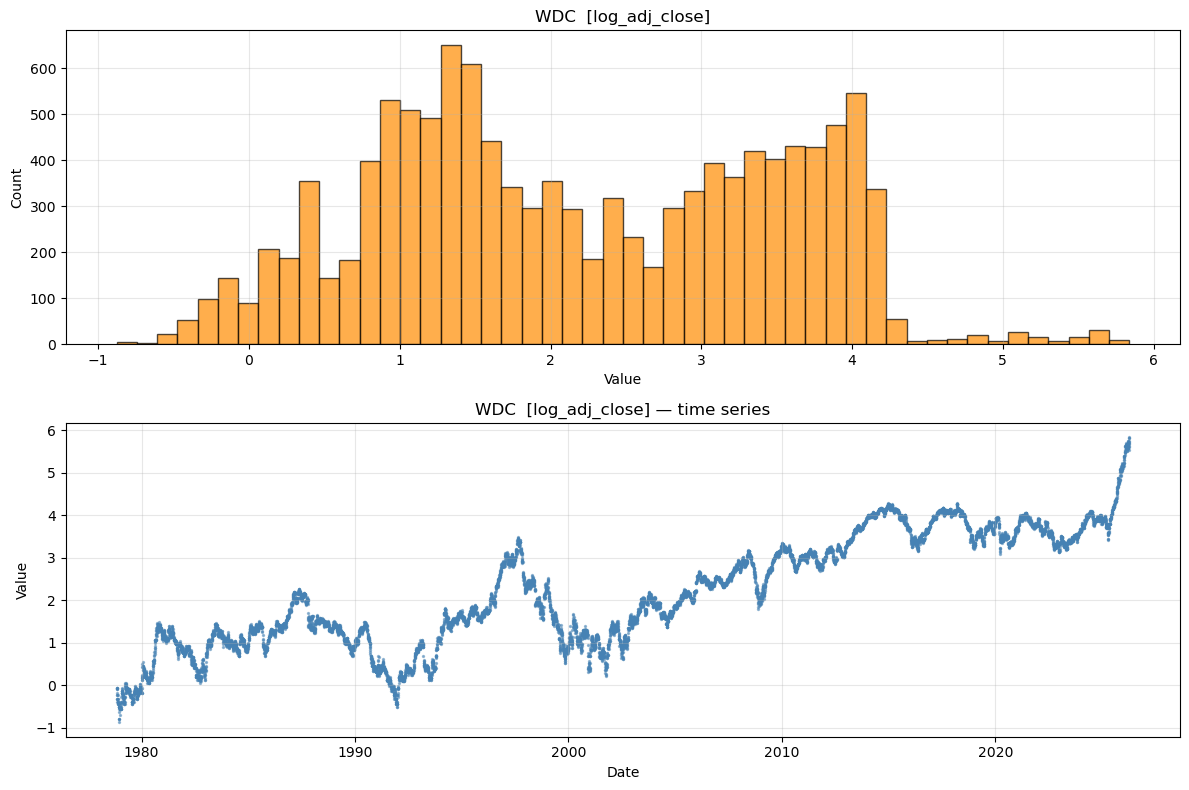


── MU  [log_adj_close] ──
count       10546.000000
mean            2.444957
std             1.435788
min            -1.094372
25%             1.621991
50%             2.596742
75%             3.523156
max             6.134560
skewness       -0.297970
kurtosis       -0.611201


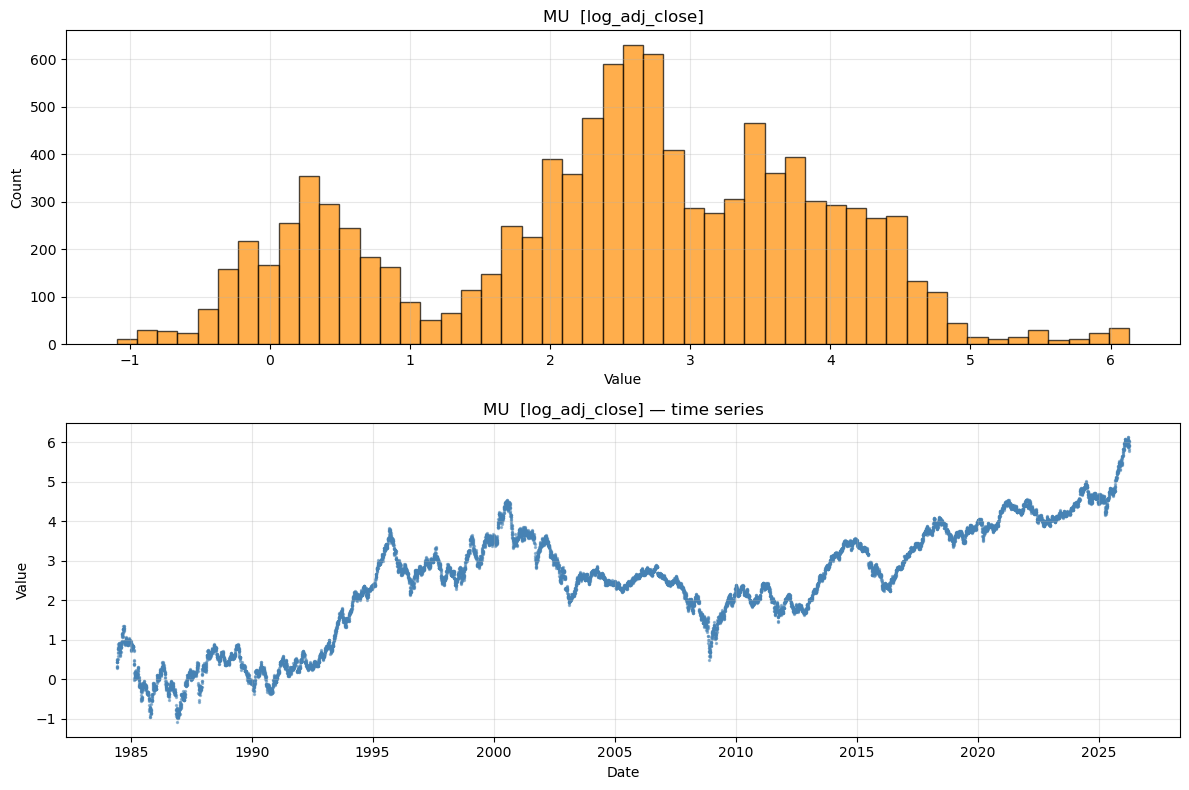


── LRCX  [log_adj_close] ──
count       10565.000000
mean            0.883712
std             1.936865
min            -2.871751
25%            -0.283052
50%             0.914024
75%             1.909397
max             5.574660
skewness        0.175888
kurtosis       -0.639000


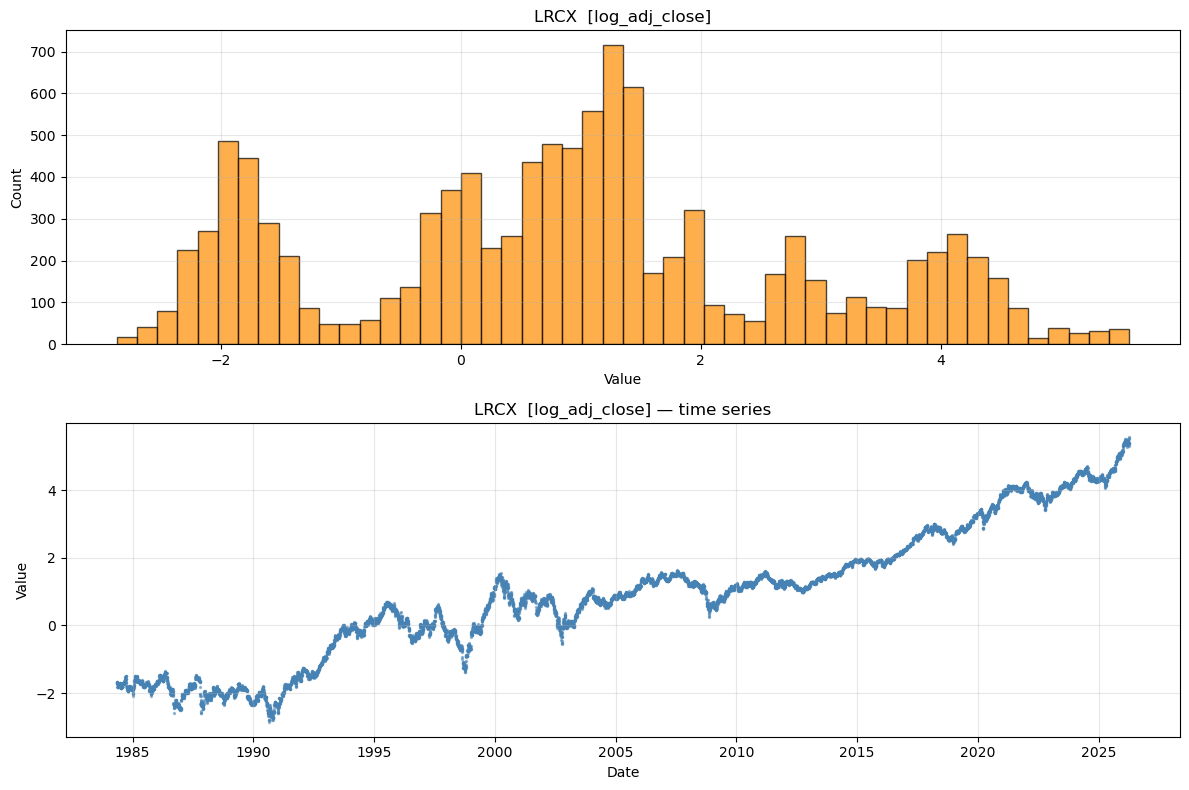


── CAT  [log_adj_close] ──
count       16176.000000
mean            2.196487
std             1.840342
min            -1.019038
25%             0.701379
50%             1.765991
75%             3.877120
max             6.672868
skewness        0.436409
kurtosis       -1.031897


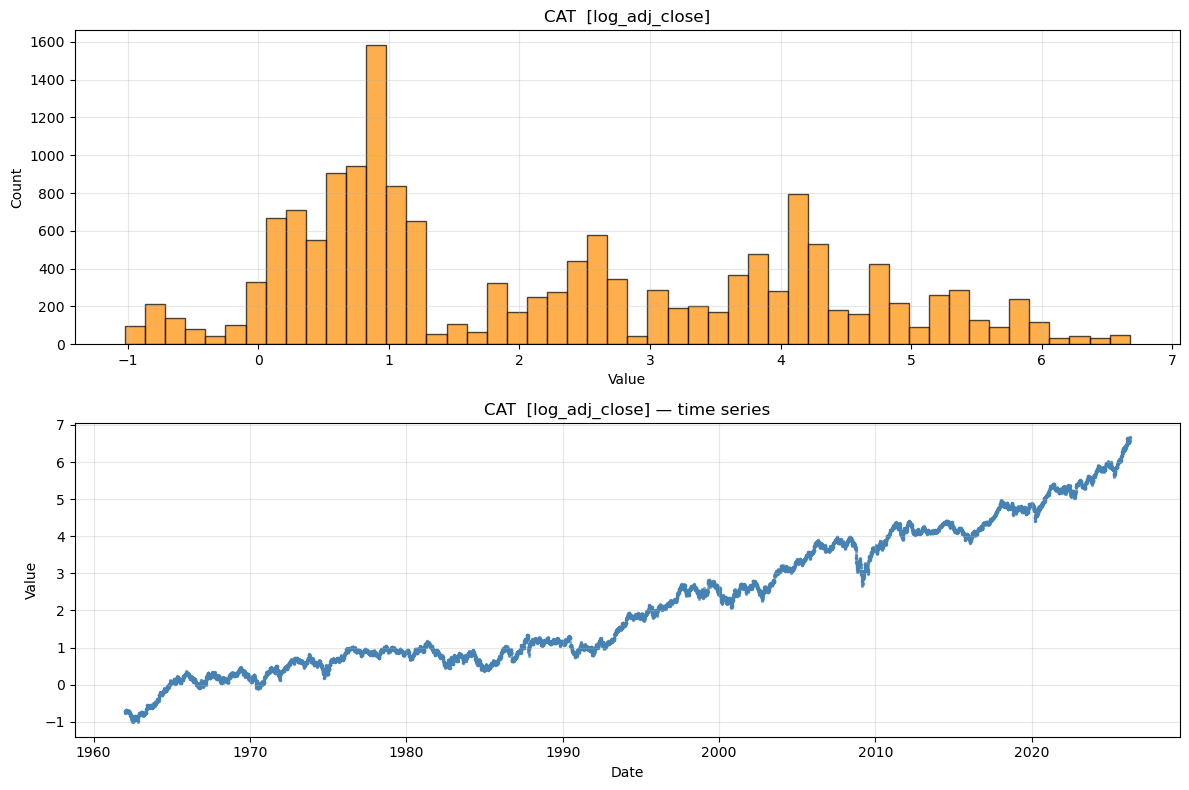


── AIG  [log_adj_close] ──
count       13431.000000
mean            4.285018
std             1.438970
min             1.475679
25%             3.239415
50%             3.937489
75%             5.299245
max             7.104034
skewness        0.454607
kurtosis       -0.905202


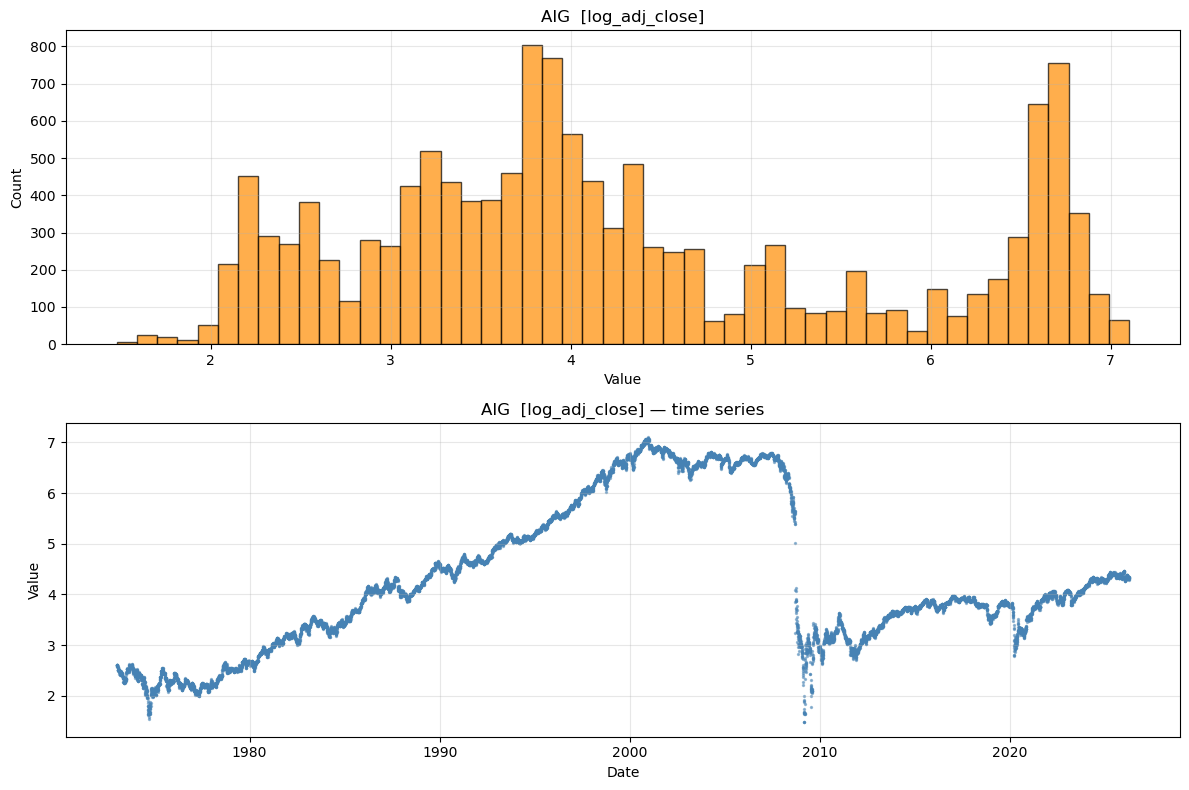


── GWW  [log_adj_close] ──
count       13397.000000
mean            3.342657
std             1.878684
min             0.011155
25%             1.710941
50%             3.349572
75%             5.088194
max             7.096566
skewness        0.133074
kurtosis       -1.043070


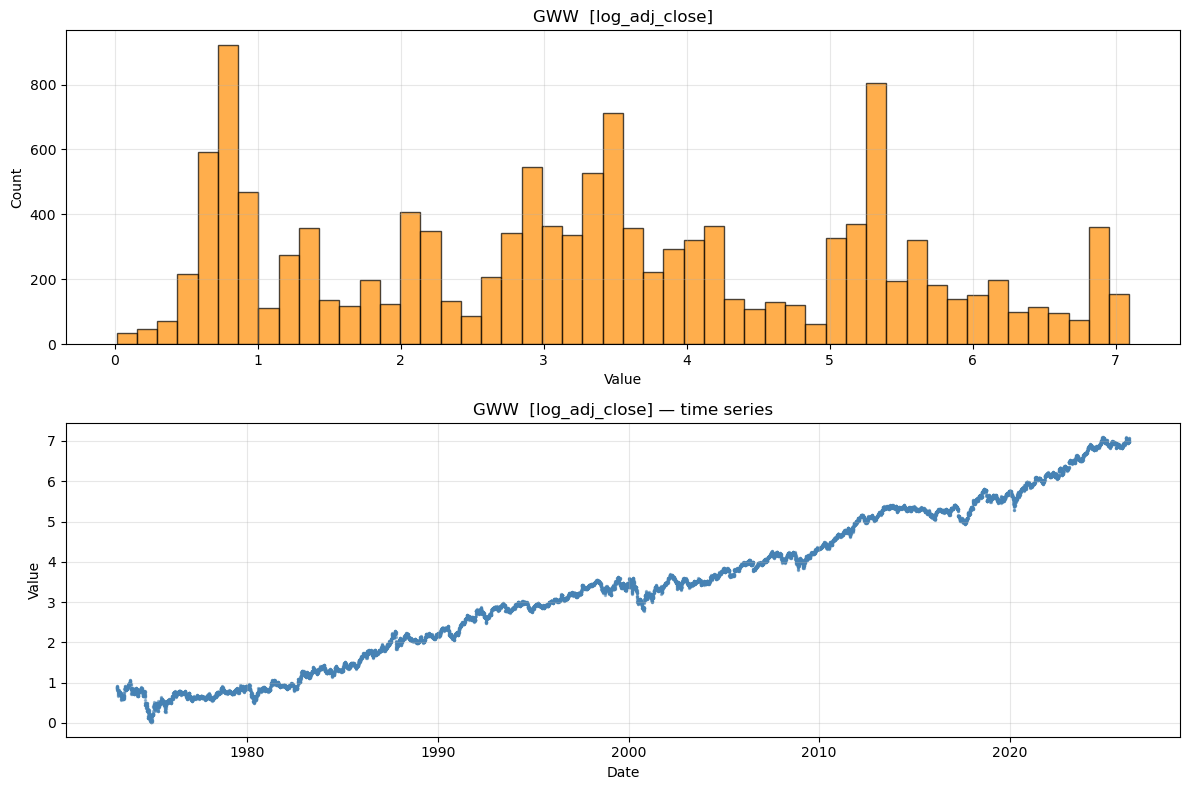

In [ ]:
# 2.7  Ticker histograms
tickers_to_plot = ['WDC', 'MU','LRCX','CAT', 'NVR', 'AIG','GWW']

plot_ticker_histograms(log_clean, tickers_to_plot, 'log_adj_close')

# Normalization

## CSV level normalization of Log-Prices
Each csv return a normalized level normalization:
`z_t = (r_t − μ) / σ`

In [ ]:
# 4.1  Normalise each ticker individually
norm_data = normalize_individually(log_clean)

Z-score normalised 210 tickers individually.


In [ ]:
# 4.2  NaN audit
norm_clean = analyze_nans(norm_data)

No NaN values found in any ticker.
Total NaNs across all tickers: 0


In [ ]:
# 4.3  Per-ticker statistics
norm_stats = compute_all_stats(norm_clean)
print(f'Statistics computed for {len(norm_stats)} tickers.')

Statistics computed for 210 tickers.


In [ ]:
# 4.4  Distribution of statistics
describe_stats(norm_stats, 'Normalised Log-Prices')


Distribution of per-ticker statistics  [Normalised Log-Prices]
              count   mean    std         min         q25      median         q75         max    skewness    kurtosis
count    210.000000  210.0  210.0  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000
mean   12493.809524   -0.0    1.0   -2.025973   -0.823645    0.107068    0.817331    1.728782   -0.185414   -0.994631
std     1699.903952    0.0    0.0    0.330661    0.158204    0.199147    0.114524    0.292738    0.338177    0.356815
min    10084.000000   -0.0    1.0   -3.288808   -1.154293   -0.524026    0.353819    1.260523   -1.015030   -1.693898
25%    11494.250000   -0.0    1.0   -2.203178   -0.942923   -0.014519    0.750047    1.536291   -0.409474   -1.239454
50%    11611.000000    0.0    1.0   -1.974210   -0.819023    0.123362    0.814774    1.687284   -0.203667   -1.028914
75%    13397.000000    0.0    1.0   -1.798529   -0.708361    0.248517    0.892309    1.853428    0.045172   -0


Aggregate statistics  [Daily Normalized Log-Prices]  (N=2,623,700)
  count       : 2,623,700
  mean        : 2.07988e-18
  std         : 0.99996
  min         : -3.28881
  q25         : -0.859407
  median      : 0.116954
  q75         : 0.821781
  max         : 2.86913
  skewness    : -0.17846
  kurtosis    : -1.01482


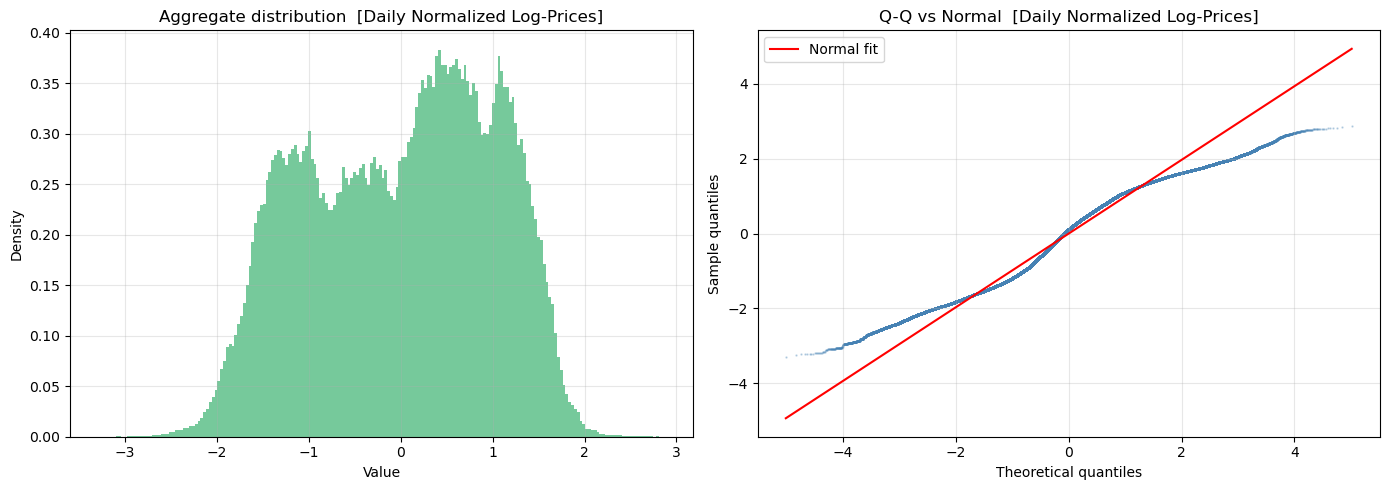

In [ ]:
norm_agg = compute_aggregate_stats_and_plot(norm_clean, 'Daily Normalized Log-Prices')

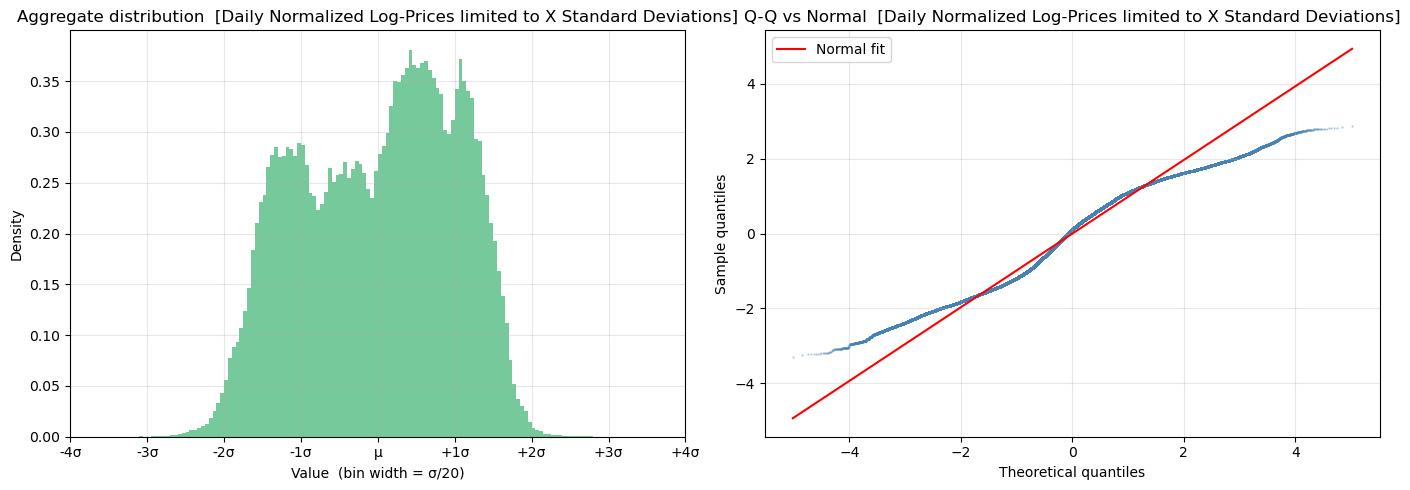

In [ ]:
compute_aggregate_stats_and_plot_std(norm_clean, 'Daily Normalized Log-Prices limited to X Standard Deviations', n_stds=4, bins_per_std=20)
print("")


── AIG  [Daily Normalized Log-Prices] ──
count       13430.000000
mean            0.000129
std             0.027112
min            -0.936258
25%            -0.008509
50%             0.000000
75%             0.009476
max             0.506818
skewness       -3.509373
kurtosis      168.169536


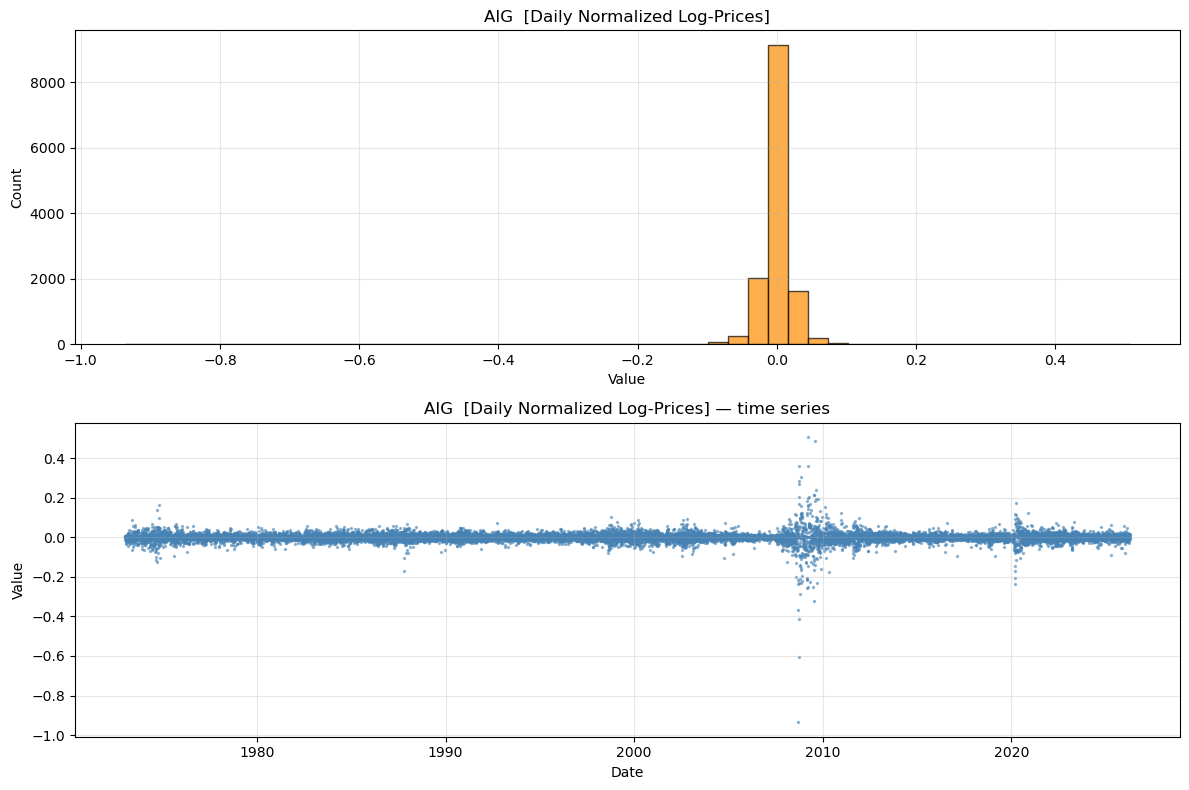


── GWW  [Daily Normalized Log-Prices] ──
count       13396.000000
mean            0.000463
std             0.017129
min            -0.147538
25%            -0.008097
50%             0.000000
75%             0.008771
max             0.170007
skewness        0.030250
kurtosis        7.347483


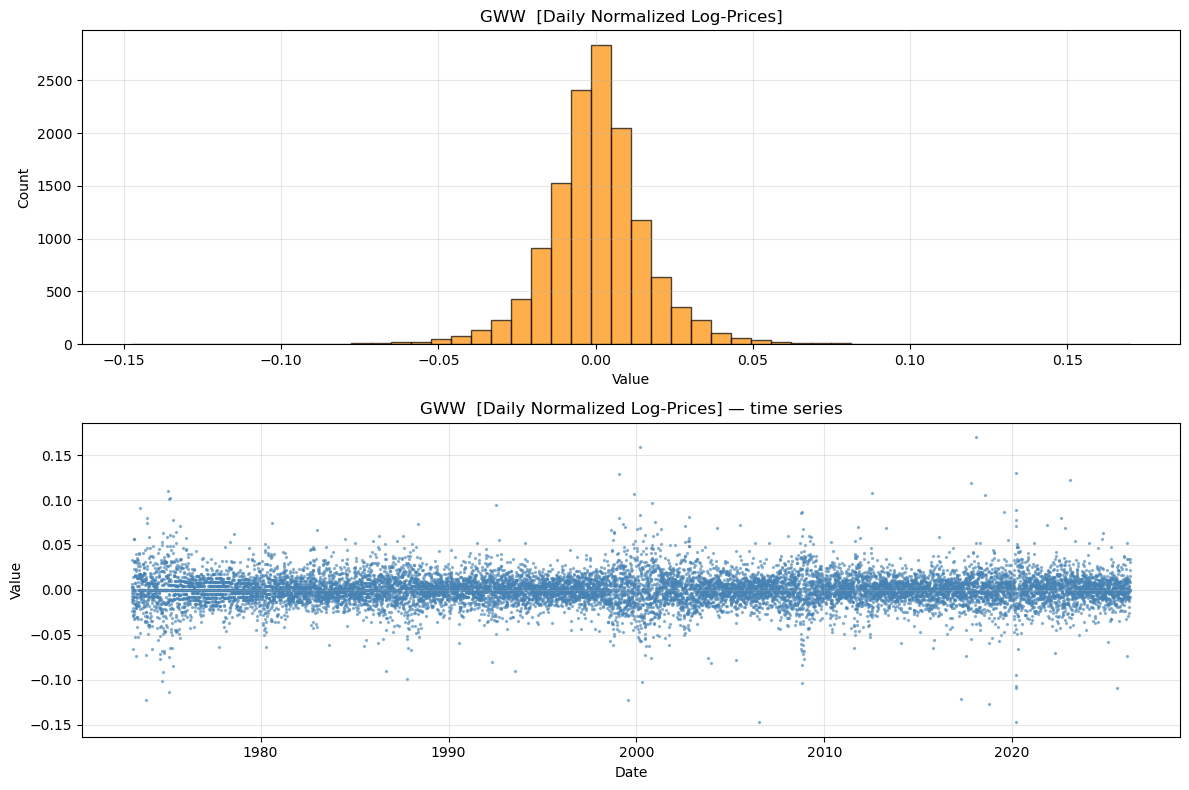


── KLAC  [Daily Normalized Log-Prices] ──
count       11467.000000
mean            0.000694
std             0.031934
min            -0.186175
25%            -0.014599
50%             0.000000
75%             0.015616
max             0.223876
skewness        0.107102
kurtosis        3.741907


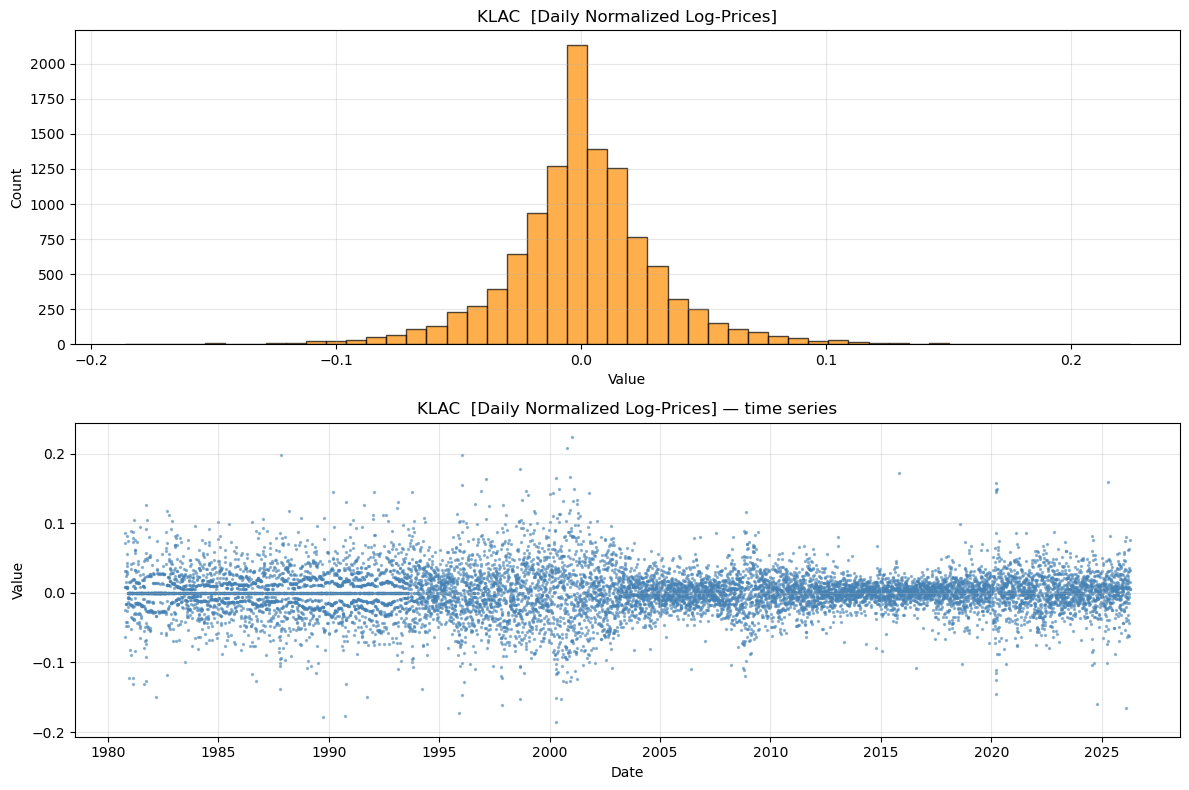


── LLY  [Daily Normalized Log-Prices] ──
count       13576.000000
mean            0.000512
std             0.017415
min            -0.345001
25%            -0.008372
50%             0.000000
75%             0.009324
max             0.153050
skewness       -0.751715
kurtosis       21.571247


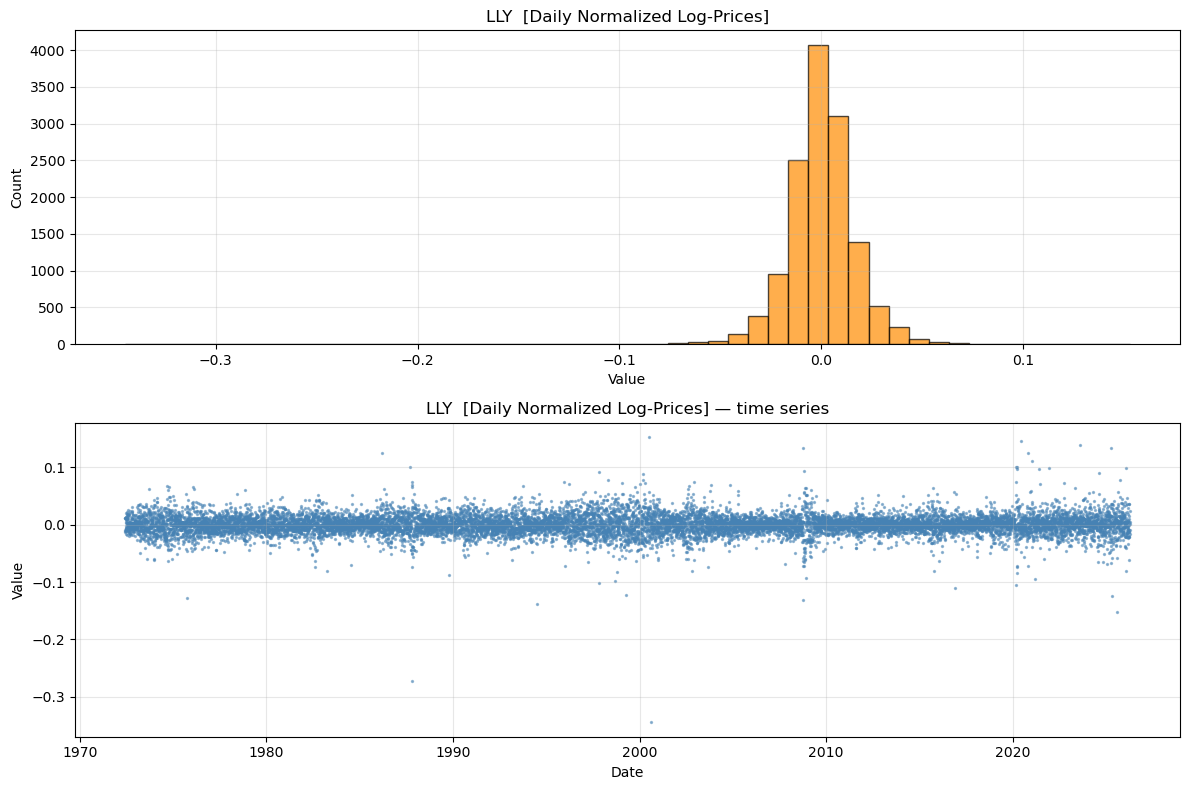


── TMO  [Daily Normalized Log-Prices] ──
count       11610.000000
mean            0.000490
std             0.019940
min            -0.206337
25%            -0.009360
50%             0.000000
75%             0.009950
max             0.163040
skewness        0.123543
kurtosis        6.849664


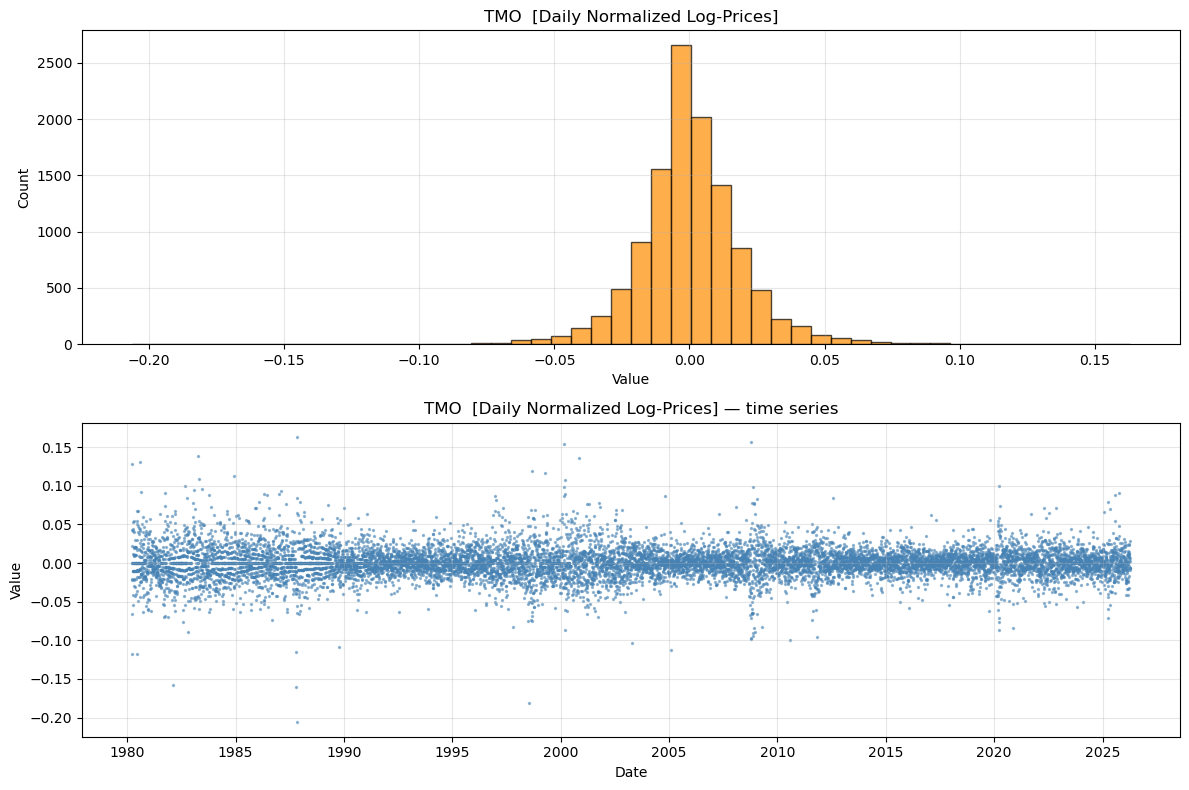


── PH  [Daily Normalized Log-Prices] ──
count       11610.000000
mean            0.000519
std             0.020230
min            -0.407459
25%            -0.009434
50%             0.000000
75%             0.010435
max             0.169063
skewness       -1.022423
kurtosis       22.503971


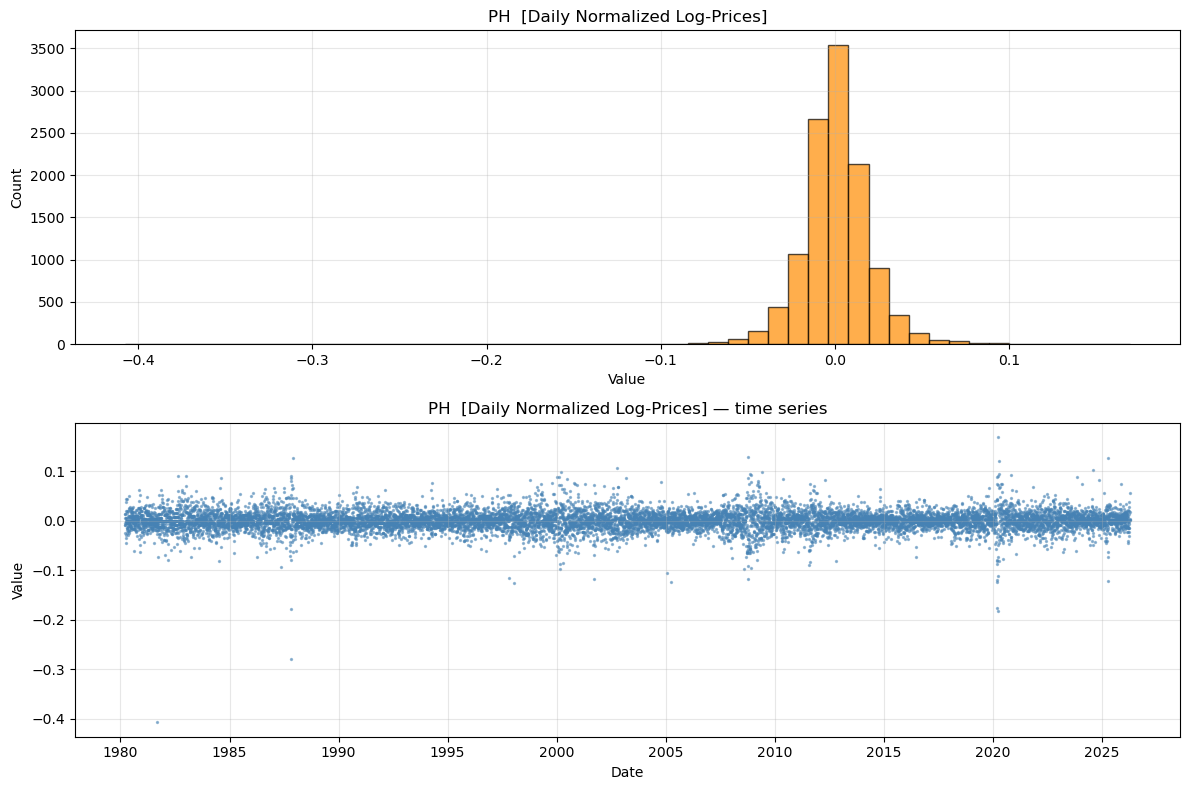


── TYL  [Daily Normalized Log-Prices] ──
count       11610.000000
mean            0.000509
std             0.031311
min            -0.569533
25%            -0.011498
50%             0.000000
75%             0.011780
max             0.298493
skewness        0.029373
kurtosis       19.485576


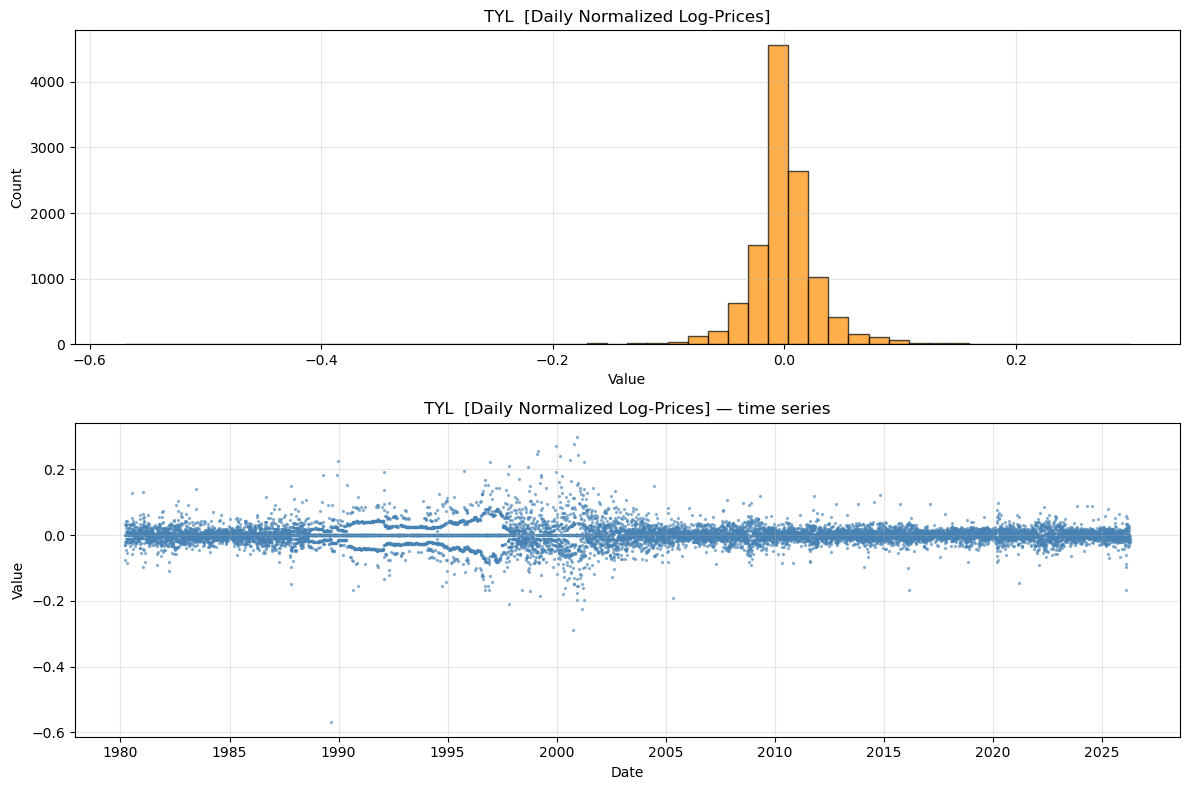

In [ ]:
tickers_to_plot = ['AIG', 'GWW', 'KLAC', 'LLY','TMO','PH','TYL']

plot_ticker_histograms(returns_filtered, tickers_to_plot, 'Daily Normalized Log-Prices')

## Window wise normalization
At each time step `t`, normalise using a rolling window of size `window_size`:  
`z_t = (x_t − μ_{t-w:t}) / σ_{t-w:t}`

Set `window_size` in the cell below.

In [ ]:
# ← SET window size here
window_size = 2048  # e.g. 252 trading days ≈ 1 year
stride = 400

In [ ]:
# 5.1  Rolling window normalisation
# ── example usage ──────────────────────────────────────────────────────────
windowed = window_normalize(log_clean, window_size=window_size, stride=stride)

window_normalize: window_size=2048, stride=400
  input tickers   : 210
  output windows  : 5,568
  avg windows/csv : 26.5
  min windows/csv : 21  (ADSK)
  max windows/csv : 36  (AEP)


In [ ]:
# still works with all existing helpers
windowed_stats = compute_all_stats(windowed)

In [ ]:
describe_stats(windowed_stats, 'Windowed normalised returns')


Distribution of per-ticker statistics  [Windowed normalised returns]
        count    mean     std          min          q25       median          q75          max     skewness     kurtosis
count  5568.0  5568.0  5568.0  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000
mean   2048.0     0.0     1.0    -2.348716    -0.743972     0.020596     0.772463     1.971007    -0.121853    -0.543324
std       0.0     0.0     0.0     0.694487     0.179357     0.211223     0.165829     0.425333     0.532540     0.977596
min    2048.0    -0.0     1.0    -8.013259    -1.326281    -0.621858    -0.161235     0.618110    -4.003026    -1.885819
25%    2048.0    -0.0     1.0    -2.643644    -0.867355    -0.128009     0.678825     1.671189    -0.438960    -1.109904
50%    2048.0     0.0     1.0    -2.195751    -0.755511     0.028536     0.783903     1.913697    -0.098923    -0.763664
75%    2048.0     0.0     1.0    -1.882302    -0.637008     0.174169     0.881850  

In [ ]:
quantile_level = 0.9
wnorm_outliers_any, wnorm_outliers_all = quantile_filter(windowed_stats, quantile_level)


90%-quantile thresholds per statistic:
count       2048.000000
mean           0.000000
std            1.000000
min           -1.649204
q25           -0.511225
median         0.291430
q75            0.975637
max            2.507874
skewness       0.529041
kurtosis       0.410502

Tickers exceeding at least one 90% threshold: 3225
           count  mean  std     min     q25  median     q75     max  skewness  kurtosis
ticker                                                                                 
AAPL_1    2048.0   0.0  1.0 -2.1173 -0.8685 -0.0661  1.0004  1.6294   -0.1666   -1.4204
AAPL_2    2048.0   0.0  1.0 -2.1593 -1.0199  0.4837  0.7364  1.5783   -0.5831   -1.0780
AAPL_3    2048.0   0.0  1.0 -3.2715 -0.1545  0.2567  0.6298  1.4607   -1.3691    1.2753
AAPL_7    2048.0  -0.0  1.0 -2.2869 -0.7015  0.0497  0.6094  2.8587    0.1948   -0.0391
AAPL_8    2048.0  -0.0  1.0 -2.0029 -0.6512 -0.0408  0.3565  2.7333    0.7321    0.3430
AAPL_9    2048.0   0.0  1.0 -2.0348 -0.6209 -0.0453 

In [ ]:
print("Max outliers")
print(wnorm_outliers_any[wnorm_outliers_any['max'] > wnorm_outliers_any['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['max'] > wnorm_outliers_any['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(3)

Max outliers
Index(['C_20', 'TAP_9', 'PG_8', 'CLX_0', 'NUE_21', 'RVTY_12', 'T_21', 'IBM_34',
       'BK_1', 'TPL_2'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
C_20,2048.0,-4.996004e-16,1.0,-4.757888,-0.510291,0.115067,0.493483,5.442088,0.894439,6.363504
TAP_9,2048.0,-8.881784e-16,1.0,-1.603567,-0.626737,-0.168921,0.345644,4.895926,1.949538,5.523261
PG_8,2048.0,2.914335e-16,1.0,-2.059942,-0.620889,-0.169337,0.345144,4.714167,1.826426,5.156062


In [ ]:
print("Std outliers")
print(wnorm_outliers_any[wnorm_outliers_any['std'] > wnorm_outliers_any['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['std'] > wnorm_outliers_any['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

Std outliers
Index(['USB_0', 'HST_8', 'EVRG_0', 'BRO_0', 'XEL_0', 'CASY_0', 'ES_0', 'CMS_0',
       'BRO_2', 'USB_5'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
USB_0,2048.0,1.165734e-15,1.0,-2.601789,-0.934120,0.531060,0.758097,1.466274,-0.718423,-0.733932
HST_8,2048.0,-2.775558e-16,1.0,-2.772569,-0.395711,0.223780,0.685587,1.609280,-1.095603,0.644674
EVRG_0,2048.0,1.387779e-16,1.0,-2.230288,-0.801390,0.048473,0.670756,2.460419,0.111387,-0.559320


In [ ]:
print("Skewness outliers")
print(wnorm_outliers_any[wnorm_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

Skewness outliers
Index(['WRB_3', 'TAP_9', 'AIG_22', 'PG_8', 'TPL_11', 'EQT_8', 'EXC_22',
       'CLX_0', 'WSM_19', 'SLB_5'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
WRB_3,2048.0,5.828671e-16,1.0,-1.262294,-0.555141,-0.260823,0.046292,3.580841,2.224199,4.328471
TAP_9,2048.0,-8.881784e-16,1.0,-1.603567,-0.626737,-0.168921,0.345644,4.895926,1.949538,5.523261
AIG_22,2048.0,2.081668e-17,1.0,-2.230962,-0.533549,-0.268814,0.128119,3.160032,1.892688,3.275839


In [ ]:
print("Kurtosis outliers")
print(wnorm_outliers_any[wnorm_outliers_any['kurtosis'] > wnorm_outliers_any['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['kurtosis'] > wnorm_outliers_any['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

Kurtosis outliers
Index(['OXY_19', 'WFC_20', 'IP_25', 'CMS_2', 'AFL_16', 'DD_21', 'IP_26',
       'DD_20', 'FITB_18', 'IP_27'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
OXY_19,2048.0,7.494005e-16,1.0,-8.013259,-0.241438,0.160434,0.471261,1.303760,-4.003026,25.121578
WFC_20,2048.0,-1.304512e-15,1.0,-7.670103,-0.438500,0.050558,0.735127,2.097252,-2.318427,10.489584
IP_25,2048.0,1.110223e-16,1.0,-5.606542,-0.027483,0.285002,0.540217,0.947973,-2.682082,7.627110



Aggregate statistics  [Daily Log-Returns]  (N=11,403,264)
  count       : 11,403,264
  mean        : 8.72907e-18
  std         : 0.999756
  min         : -8.01326
  q25         : -0.762472
  median      : 0.0254226
  q75         : 0.785962
  max         : 5.44209
  skewness    : -0.121853
  kurtosis    : -0.543324


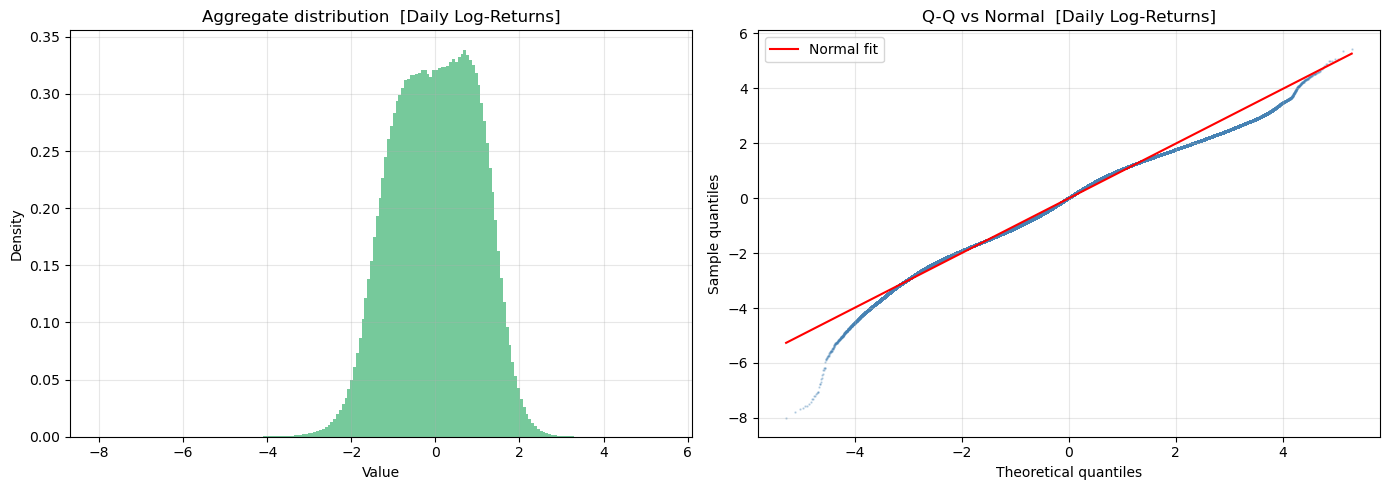

In [ ]:
# 3.8  Aggregate statistics + distribution across ALL tickers combined
wnorm_agg = compute_aggregate_stats_and_plot(windowed, 'Daily Window Normalized Log-Prices')

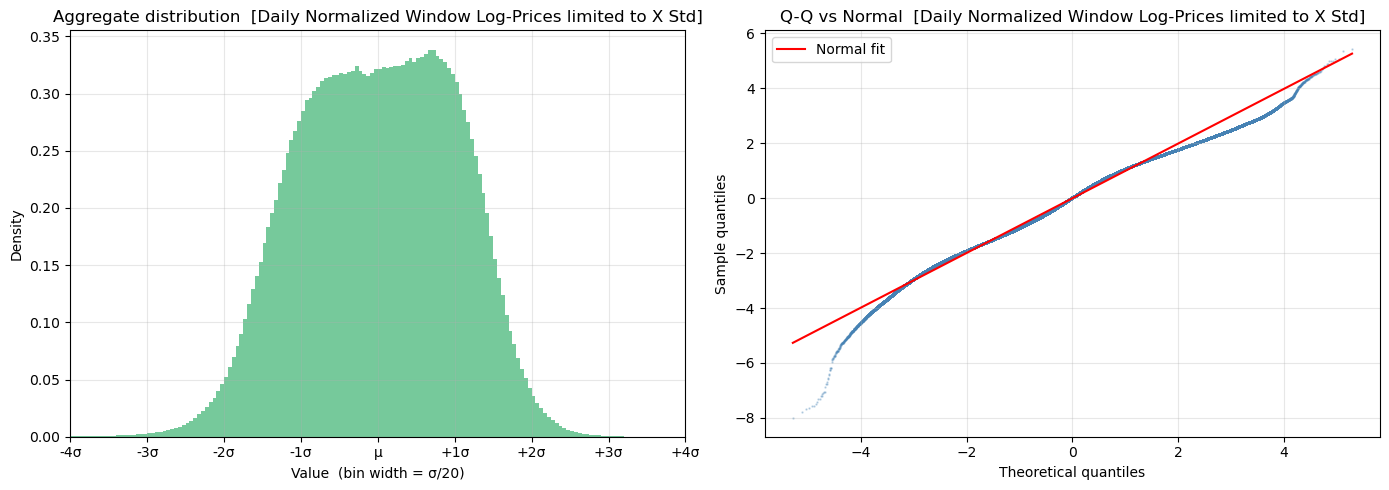

{'count': 11403264,
 'mean': 8.729073697901972e-18,
 'std': 0.9997558295653994,
 'min': -8.013258799754826,
 'q25': -0.762472309083201,
 'median': 0.025422596069511756,
 'q75': 0.7859624508292358,
 'max': 5.442087740036283,
 'skewness': -0.5433235751353411}

In [ ]:
compute_aggregate_stats_and_plot_std(windowed, 'Daily Normalized Window Log-Prices limited to X Std', n_stds=4, bins_per_std=20)

# Window starter at 0

In [ ]:
# ── example usage ──────────────────────────────────────────────────────────
rebased = window_rebase(log_clean, window_size=2048, stride=400)

window_rebase: window_size=2048, stride=400
  input tickers   : 210
  output windows  : 5,568
  avg windows/csv : 26.5
  min windows/csv : 21  (ADSK)
  max windows/csv : 36  (AEP)


In [ ]:
rebased_stats = compute_all_stats(rebased)

In [ ]:
describe_stats(rebased_stats, 'Rebased windows (start = 0)')


Distribution of per-ticker statistics  [Rebased windows (start = 0)]
        count         mean          std          min          q25       median          q75          max     skewness     kurtosis
count  5568.0  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000  5568.000000
mean   2048.0     0.471032     0.377319    -0.368947     0.181551     0.477193     0.770056     1.191839    -0.121853    -0.543324
std       0.0     0.446941     0.179273     0.485097     0.398835     0.476527     0.551843     0.642391     0.532540     0.977596
min    2048.0    -2.934573     0.069461    -5.430630    -3.654112    -3.286220    -2.812204     0.000000    -4.003026    -1.885819
25%    2048.0     0.216260     0.248193    -0.489966     0.000000     0.187689     0.408711     0.755913    -0.438960    -1.109904
50%    2048.0     0.466989     0.344856    -0.206465     0.197915     0.457705     0.725047     1.120279    -0.098923    -0.763664
75%    2048.0

In [ ]:
quantile_level = 0.9
wnorm_outliers_any, wnorm_outliers_all = quantile_filter(rebased_stats, quantile_level)


90%-quantile thresholds per statistic:
count       2048.000000
mean           0.989353
std            0.599812
min           -0.016446
q25            0.600211
median         1.044286
q75            1.458883
max            2.001428
skewness       0.529041
kurtosis       0.410502

Tickers exceeding at least one 90% threshold: 2235
           count    mean     std     min     q25  median     q75     max  skewness  kurtosis
ticker                                                                                      
AAPL_1    2048.0  1.2441  0.6064 -0.0400  0.7174  1.2040  1.8508  2.2322   -0.1666   -1.4204
AAPL_2    2048.0  0.8346  0.6271 -0.5194  0.1951  1.1379  1.2964  1.8243   -0.5831   -1.0780
AAPL_3    2048.0  1.5640  0.4881 -0.0328  1.4886  1.6893  1.8714  2.2770   -1.3691    1.2753
AAPL_8    2048.0  0.2631  0.5091 -0.7565 -0.0684  0.2423  0.4446  1.6545    0.7321    0.3430
AAPL_9    2048.0 -0.0698  0.5100 -1.1076 -0.3864 -0.0929  0.1442  1.3034    0.6402    0.2163
AAPL_11   2048.0 

In [ ]:
print("Max outliers")
print(wnorm_outliers_any[wnorm_outliers_any['max'] > wnorm_outliers_any['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['max'] > wnorm_outliers_any['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(3)

Max outliers
Index(['MNST_10', 'MNST_11', 'JKHY_3', 'MNST_9', 'ORCL_4', 'AMGN_1', 'HAS_0',
       'SWKS_5', 'UNH_2', 'MNST_8'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST_10,2048.0,2.795895,1.789228,-0.029862,0.648012,3.507313,4.405130,5.076781,-0.430003,-1.511245
MNST_11,2048.0,3.471767,1.347929,-0.002374,2.835855,4.132411,4.360117,5.068385,-1.244017,0.225377
JKHY_3,2048.0,3.093828,1.213711,-0.080049,2.427661,3.073430,4.200751,5.059823,-0.671885,-0.057367


In [ ]:
print("Std outliers")
print(wnorm_outliers_any[wnorm_outliers_any['std'] > wnorm_outliers_any['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['std'] > wnorm_outliers_any['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

Std outliers
Index(['MNST_9', 'MNST_10', 'AIG_20', 'AIG_19', 'AIG_21', 'HAS_0', 'MNST_8',
       'UNH_2', 'JKHY_2', 'MNST_11'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST_9,2048.0,1.778120,1.858959,-0.357101,-0.000447,1.212977,3.980341,4.868457,0.335675,-1.597301
MNST_10,2048.0,2.795895,1.789228,-0.029862,0.648012,3.507313,4.405130,5.076781,-0.430003,-1.511245
AIG_20,2048.0,-1.968249,1.774604,-5.275334,-3.654112,-3.071800,-0.107417,0.033520,0.000178,-1.885819


In [ ]:
print("Skewness outliers")
print(wnorm_outliers_any[wnorm_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

Skewness outliers
Index(['WRB_3', 'TAP_9', 'AIG_22', 'PG_8', 'TPL_11', 'EQT_8', 'EXC_22',
       'CLX_0', 'WSM_19', 'SLB_5'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
WRB_3,2048.0,0.407707,0.371018,-0.060627,0.201739,0.310937,0.424882,1.736264,2.224199,4.328471
TAP_9,2048.0,0.028520,0.167185,-0.239573,-0.076261,0.000279,0.086307,0.847048,1.949538,5.523261
AIG_22,2048.0,-2.934573,0.955113,-5.065394,-3.444172,-3.191321,-2.812204,0.083616,1.892688,3.275839


In [ ]:
print("Kurtosis outliers")
print(wnorm_outliers_any[wnorm_outliers_any['kurtosis'] > wnorm_outliers_any['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
wnorm_outliers_any[wnorm_outliers_any['kurtosis'] > wnorm_outliers_any['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

Kurtosis outliers
Index(['OXY_19', 'WFC_20', 'IP_25', 'CMS_2', 'AFL_16', 'DD_21', 'IP_26',
       'DD_20', 'FITB_18', 'IP_27'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
OXY_19,2048.0,-0.196795,0.221901,-1.974947,-0.250371,-0.161195,-0.092222,0.092511,-4.003026,25.121578
WFC_20,2048.0,0.142701,0.159847,-1.083346,0.072608,0.150782,0.260209,0.477941,-2.318427,10.489584
IP_25,2048.0,0.046532,0.339004,-1.854107,0.037215,0.143149,0.229668,0.367899,-2.682082,7.627110



Aggregate statistics  [Daily Window Normalized Log-Prices]  (N=11,403,264)
  count       : 11,403,264
  mean        : 0.471032
  std         : 0.611668
  min         : -5.43063
  q25         : 0.0789687
  median      : 0.399775
  q75         : 0.810182
  max         : 5.07678
  skewness    : 0.424574
  kurtosis    : 3.18898


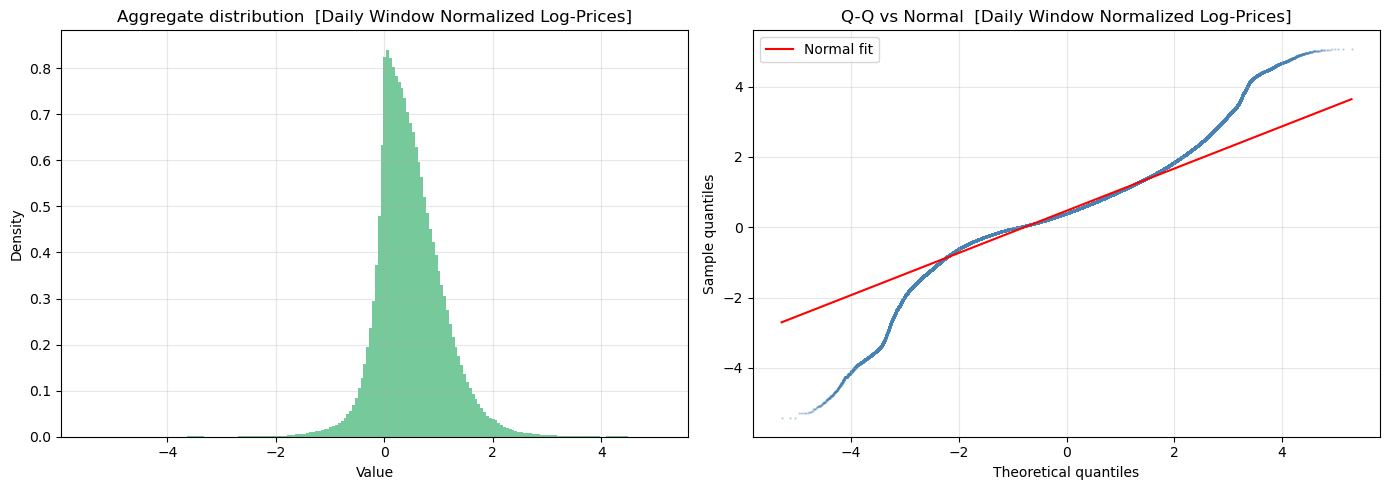

In [ ]:
# 3.8  Aggregate statistics + distribution across ALL tickers combined
wnorm_agg = compute_aggregate_stats_and_plot(rebased, 'Daily Window Normalized Log-Prices')

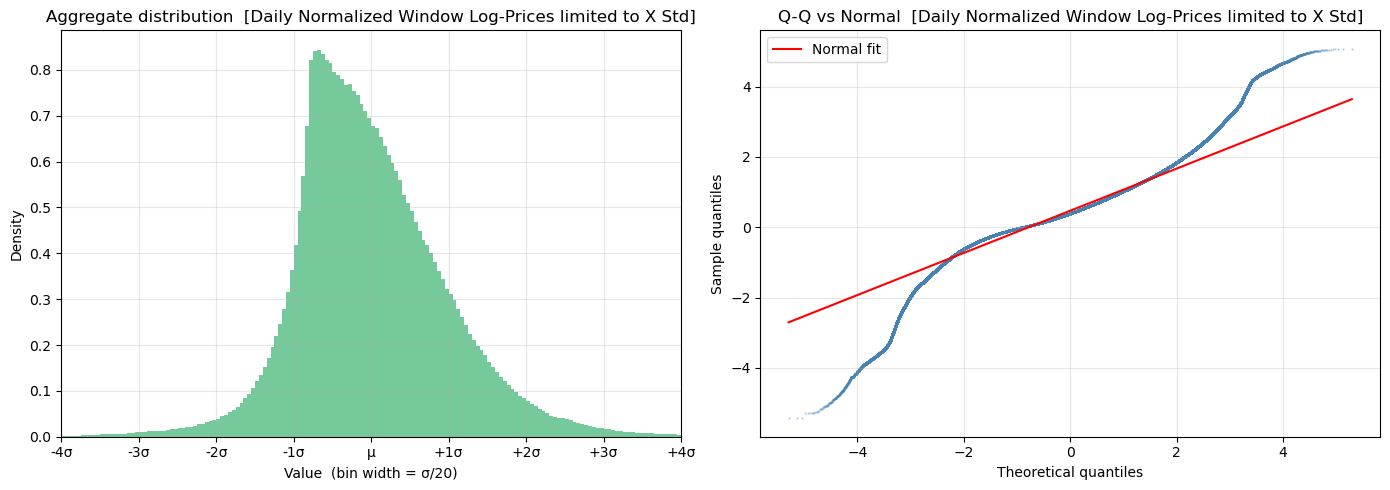

{'count': 11403264,
 'mean': 0.4710320887887239,
 'std': 0.6116677213047863,
 'min': -5.430629913454384,
 'q25': 0.07896869476279866,
 'median': 0.3997748707592499,
 'q75': 0.8101823973345395,
 'max': 5.0767806767052654,
 'skewness': 3.188977695860464}

In [ ]:
compute_aggregate_stats_and_plot_std(rebased, 'Daily Normalized Window Log-Prices limited to X Std', n_stds=4, bins_per_std=20)